In [4]:

# ================================
# 1. Imports
# ================================
import os, ast, re
import networkx as nx
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from typing import List, Dict, Any, Optional

# ================================
# 2. Parse codebase into chunks & call relations
# ================================

---

### 🔎 **AST Node Types for Functions, Methods, and Calls**

| **AST Node**                  | **When It Appears in Code**                                  | **Key Fields / Attributes**                                              | **Useful For**                            |
| ----------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------ | ----------------------------------------- |
| `ast.FunctionDef`             | A regular function definition (`def foo(x): ...`)            | `.name`, `.args`, `.body`, `.decorator_list`                             | Detecting top-level functions or methods. |
| `ast.AsyncFunctionDef`        | An async function (`async def foo(): ...`)                   | Same fields as `FunctionDef`                                             | Handling async code.                      |
| `ast.Lambda`                  | A lambda function (`lambda x: x+1`)                          | `.args`, `.body`                                                         | Capturing inline anonymous functions.     |
| `ast.ClassDef`                | A class definition (`class MyClass:`)                        | `.name`, `.bases` (inheritance), `.body`, `.decorator_list`              | Extracting class structure and methods.   |
| `ast.Call`                    | Any function/method call (`foo(x)`, `obj.method(y)`)         | `.func` (the function being called), `.args`, `.keywords`                | Building call graphs.                     |
| `ast.Attribute`               | Attribute access (`obj.method`, `self.attr`)                 | `.value` (object), `.attr` (string of attribute name)                    | Resolving method calls and attributes.    |
| `ast.Name`                    | A variable or function name (`foo`, `bar`)                   | `.id` (name string)                                                      | Identifying callee name in calls.         |
| `ast.arguments`               | Function arguments container                                 | `.args`, `.vararg`, `.kwonlyargs`, `.kw_defaults`, `.kwarg`, `.defaults` | Inspecting function signatures.           |
| `ast.arg`                     | A single function argument (`x` in `def foo(x): ...`)        | `.arg` (name), `.annotation` (if type hinted)                            | Detailed argument info.                   |
| `ast.Return`                  | Return statement (`return x+y`)                              | `.value`                                                                 | Tracing outputs of functions.             |
| `ast.Yield` / `ast.YieldFrom` | Yield expressions in generators (`yield x`, `yield from it`) | `.value`                                                                 | Detecting generator functions.            |

---

### 📦 **How These Nodes Fit Together**

* **Functions:**

  ```python
  def foo(x, y=1): return x+y
  ```

  → `FunctionDef` with `arguments` containing `arg(x), arg(y)`, body includes `Return`.

* **Classes + Methods:**

  ```python
  class A:
      def method(self): pass
  ```

  → `ClassDef` node with a `FunctionDef` inside its `.body`.

* **Calls:**

  ```python
  foo(42)            # Call(Name('foo'))
  obj.bar(1)         # Call(Attribute(Name('obj'), 'bar'))
  ```

  → Always `ast.Call` with `.func` = `Name` or `Attribute`.

---

### 🔧 **Quick Example AST Parse**

```python
import ast

code = """
class A:
    def add(self, x, y): return x+y

def square(n): return n*n

result = A().add(2,3)
"""

tree = ast.parse(code)
for node in ast.walk(tree):
    print(type(node).__name__, getattr(node, "name", None))
```

**Output (simplified):**

```
Module None
ClassDef A
FunctionDef add
FunctionDef square
Call None
Attribute add
Name A
Name result
```

---

### ✅ Typical Things You’ll Look For in Repo Parsing

* **Functions & methods** → `FunctionDef`, `AsyncFunctionDef`, `Lambda`
* **Classes** → `ClassDef`
* **Function calls** → `Call` (with `Name` or `Attribute`)
* **Imports** → `Import`, `ImportFrom` (to track dependencies)
* **Decorators** → from `FunctionDef.decorator_list`

---

In [5]:
def parse_codebase(project_root: str):
    """
    Parse and analyze a Python project into structured code representations enriched
    with static analysis metadata, suitable for downstream tasks such as
    retrieval-augmented generation (RAG), knowledge graph construction, and
    repository comprehension.

    This function performs a recursive walk over all `.py` files within the given
    project directory and uses Python's Abstract Syntax Tree (AST) to extract
    semantic entities — classes, functions, and lambdas — along with their
    relationships, metadata, and structural information.

    **Core Features**
    -----------------
    - **Entity Extraction**:
        - Classes (`ast.ClassDef`)
        - Functions (`ast.FunctionDef`, `ast.AsyncFunctionDef`)
        - Methods (functions bound to classes, including static/class/property methods)
        - Lambdas (`ast.Lambda`)
    - **Metadata Enrichment** for each entity:
        - Names, qualified identifiers, file location, and original source code.
        - Signatures and structured argument lists, including defaults and annotations.
        - Return/yield statements, generator status, and raises/exception handling.
        - Local variables and instance attributes, with inferred types and previews.
        - Decorators, method kinds (instance, staticmethod, classmethod, property).
        - Docstrings and parsed docstring sections (summary, parameters, returns, raises, etc.).
        - Comments within the source span.
        - Metrics: number of lines of code (LOC), number of params, returns, yields,
          branches, calls.
    - **Call Graph Extraction**:
        - Each function/method call within bodies is recorded with:
          - Caller unique ID
          - Callee name (simple)
          - Callee full dotted name (best effort)
          - Callsite line number
        - Relations are deduplicated for stability.

    **Outputs**
    -----------
    Returns:
        tuple[list[dict], list[dict]]

        1. **code_chunks** (list of dict):
            Each entry represents a semantic code unit. Example structure:
            ```python
            {
                "id": "/abs/path/module.py::function::load_config",
                "type": "function",       # one of {"class", "function", "lambda"}
                "name": "load_config",    # short name
                "file": "/abs/path/module.py",
                "code": "def load_config(path): ...",
                "meta": {
                    "decorators": [],
                    "method_kind": "instance" | "staticmethod" | "classmethod" | "property",
                    "is_async": False,
                    "is_method": False,
                    "class_name": None,
                    "signature": "(path)",
                    "parameters": [
                        {"name": "path", "annotation": None, "kind": "pos_or_kw", "default": None}
                    ],
                    "args_struct": {...},       # original AST arguments structure
                    "returns_annotation": None,
                    "docstring": "Optional raw docstring",
                    "doc_parsed": {
                        "summary": "Short summary",
                        "params": [{"name": "path", "type": "str", "desc": "Path to config file"}],
                        "returns": "Config object",
                        "raises": ["IOError"],
                        ...
                    },
                    "is_generator": False,
                    "return_values": ["config"],
                    "yield_values": [],
                    "raises": ["IOError"],
                    "exceptions_handled": [],
                    "attributes_used": ["self.attr"],
                    "names_used": ["config", "open"],
                    "imports_used": {"os": "os"},
                    "lambda_ids": [],
                    "calls_detailed": [
                        {"callee_fullname": "json.load",
                         "callee_name": "load",
                         "args": ["f"],
                         "keywords": {},
                         "lineno": 42}
                    ],
                    "local_vars": [
                        {"name": "config", "annotation": None,
                         "inferred_type": "dict", "value_preview": "{}", "lineno": 41}
                    ],
                    "instance_attributes": [],
                    "metrics": {
                        "n_loc": 12,
                        "n_params": 1,
                        "n_returns": 1,
                        "n_yields": 0,
                        "n_branches": 0,
                        "n_calls": 2
                    },
                    "comments": ["# TODO: handle errors"]
                }
            }
            ```

        2. **call_relations** (list of dict):
            Directed call edges between code entities. Example:
            ```python
            {
                "caller_id": "/abs/path/module.py::function::run",
                "callee_name": "load_config",
                "callee_fullname": "utils.load_config",
                "lineno": 58
            }
            ```

    **Notes**
    ---------
    - Node IDs are globally unique, formed by combining file path and semantic role
      (e.g., `/path/to/file.py::class::MyClass`, `/path/to/file.py::method::MyClass.foo`).
    - Function call resolution is **name-based only**. Full dotted names are extracted
      heuristically but are not guaranteed to resolve across imports.
    - The analysis is **static**: it does not execute code and may not capture
      runtime-specific behavior such as dynamic attributes or monkey-patching.
    - Designed to support:
        * Building knowledge graphs of code
        * Enabling semantic search across codebases
        * Powering RAG pipelines with detailed code context

    Example:
        >>> chunks, calls = parse_codebase("/project")
        >>> chunks[0]["meta"]["signature"]
        '(path, *, encoding="utf-8")'
        >>> calls[0]
        {
            'caller_id': '/project/main.py::function::run',
            'callee_name': 'load_config',
            'callee_fullname': 'utils.load_config',
            'lineno': 58
        }
    """
    # Storage for extracted code entities and call relations
    code_chunks: List[Dict[str, Any]] = []
    call_relations: List[Dict[str, Any]] = []

    # ---------- helpers ----------

    def _unparse(node: Optional[ast.AST]) -> Optional[str]:
        # Try to turn AST node back into source code text
        if node is None:
            return None
        try:
            return ast.unparse(node)
        except Exception:
            # Fallback: use attributes if unparse fails
            return getattr(node, "id", None) or getattr(node, "attr", None) or type(node).__name__

    def _get_source(source: str, node: ast.AST) -> str:
        # Safely extract original source segment for node
        try:
            seg = ast.get_source_segment(source, node)
            return seg if seg is not None else ""
        except Exception:
            return ""

    def _dotted_attr(node: ast.AST) -> Optional[str]:
        # Recursively reconstruct dotted attribute names
        if isinstance(node, ast.Attribute):
            left = _dotted_attr(node.value)
            return f"{left}.{node.attr}" if left else node.attr
        if isinstance(node, ast.Name):
            return node.id
        return _unparse(node)

    def _serialize_arg(a: ast.arg) -> Dict[str, Any]:
        # Convert AST argument node to dict with metadata
        return {
            "name": a.arg,
            "annotation": _unparse(getattr(a, "annotation", None)),
            "type_comment": getattr(a, "type_comment", None) if hasattr(a, "type_comment") else None,
        }

    
    def _param_list(args: ast.arguments) -> List[Dict[str, Any]]:
        # Flatten function parameters into structured list with kinds and defaults
        params: List[Dict[str, Any]] = []

        # Pos-only args
        for a in getattr(args, "posonlyargs", []):
            params.append({**_serialize_arg(a), "kind": "posonly", "default": None})

        # Regular args with defaults
        reg = list(args.args)
        ndef = len(args.defaults or [])
        for i, a in enumerate(reg):
            default = None
            if ndef and i >= len(reg) - ndef:
                j = i - (len(reg) - ndef)
                default = _unparse(args.defaults[j])
            params.append({**_serialize_arg(a), "kind": "pos_or_kw", "default": default})

        # *args
        if args.vararg:
            params.append({**_serialize_arg(args.vararg), "kind": "vararg", "default": None})

        # Keyword-only args
        kwdefs = args.kw_defaults or []
        for i, a in enumerate(args.kwonlyargs):
            default = _unparse(kwdefs[i]) if i < len(kwdefs) and kwdefs[i] is not None else None
            params.append({**_serialize_arg(a), "kind": "kwonly", "default": default})

        # **kwargs
        if args.kwarg:
            params.append({**_serialize_arg(args.kwarg), "kind": "kwarg", "default": None})

        return params

    def _signature_str(args: ast.arguments) -> str:
        # Human-friendly signature reconstruction
        parts: List[str] = []
        try:
            po = getattr(args, "posonlyargs", [])
            for a in po:
                seg = a.arg + (f": {_unparse(a.annotation)}" if a.annotation else "")
                parts.append(seg)
            if po:
                parts.append("/")
            reg = list(args.args)
            ndef = len(args.defaults or [])
            for i, a in enumerate(reg):
                ann = f": {_unparse(a.annotation)}" if a.annotation else ""
                if ndef and i >= len(reg) - ndef:
                    j = i - (len(reg) - ndef)
                    parts.append(f"{a.arg}{ann}={_unparse(args.defaults[j])}")
                else:
                    parts.append(f"{a.arg}{ann}")
            if args.vararg:
                a = args.vararg
                parts.append(f"*{a.arg}" + (f": {_unparse(a.annotation)}" if a.annotation else ""))
            elif args.kwonlyargs:
                parts.append("*")
            for a, d in zip(args.kwonlyargs, args.kw_defaults or [None]*len(args.kwonlyargs)):
                seg = a.arg + (f": {_unparse(a.annotation)}" if a.annotation else "")
                if d is not None:
                    seg += f"={_unparse(d)}"
                parts.append(seg)
            if args.kwarg:
                a = args.kwarg
                parts.append(f"**{a.arg}" + (f": {_unparse(a.annotation)}" if a.annotation else ""))
            return "(" + ", ".join(parts) + ")"
        except Exception:
            return "()"

    def _infer_type(node: Optional[ast.AST]) -> Optional[str]:
        # Heuristic static type inference for literals and structures
        try:
            if node is None:
                return None
            if isinstance(node, ast.Constant):
                v = node.value
                if v is None: return "NoneType"
                return type(v).__name__
            if isinstance(node, (ast.List, ast.ListComp)):   return "list"
            if isinstance(node, (ast.Tuple, ast.GeneratorExp)): return "tuple"
            if isinstance(node, (ast.Set, ast.SetComp)):     return "set"
            if isinstance(node, (ast.Dict, ast.DictComp)):   return "dict"
            if isinstance(node, ast.Call):
                fn = _dotted_attr(node.func) or _unparse(node.func) or "call"
                return f"{fn}()"
            if isinstance(node, ast.Name):       return f"Symbol:{node.id}"
            if isinstance(node, ast.Attribute):  return f"Attr:{_dotted_attr(node)}"
            return type(node).__name__
        except Exception:
            return None

    def _value_preview(node: Optional[ast.AST], maxlen: int = 160) -> Optional[str]:
        # Preview a value expression as string, truncated if long
        try:
            if node is None: return None
            s = _unparse(node) or ""
            if s and len(s) > maxlen:
                return s[: maxlen - 3] + "..."
            return s or None
        except Exception:
            return None

    def _comments_by_line(source: str) -> Dict[int, List[str]]:
        # Extract comments indexed by line number
        result: Dict[int, List[str]] = {}
        try:
            for tok in tokenize.generate_tokens(io.StringIO(source).readline):
                if tok.type == tokenize.COMMENT:
                    result.setdefault(tok.start[0], []).append(tok.string)
        except Exception:
            pass
        return result

    def _comments_in_span(cmap: Dict[int, List[str]], start: int, end: int) -> List[str]:
        # Collect comments within source span
        out: List[str] = []
        for ln in range(start, end + 1):
            if ln in cmap:
                out.extend(cmap[ln])
        return out

    def _parse_docstring(docstring: Optional[str]) -> Optional[Dict[str, Any]]:
        # Parse docstring into structured sections
        if not docstring:
            return None
        try:
            lines = [ln.rstrip() for ln in docstring.splitlines()]
            sections = {"summary": None, "params": [], "returns": None, "yields": None, "raises": [], "notes": []}
            for ln in lines:
                if ln.strip():
                    sections["summary"] = ln.strip()
                    break
            state = None
            buf: List[str] = []
            def flush():
                nonlocal buf, state
                text = "\n".join(buf).strip()
                if not text:
                    buf = []
                    return
                if state in ("Args", "Parameters"):
                    for raw in text.splitlines():
                        if not raw.strip():
                            continue
                        name, type_, desc = None, None, raw.strip()
                        if ":" in raw:
                            head, desc = raw.split(":", 1)
                            head = head.strip()
                            desc = desc.strip()
                            if "(" in head and head.endswith(")"):
                                try:
                                    name = head[: head.index("(")].strip()
                                    type_ = head[head.index("(")+1 : -1].strip()
                                except Exception:
                                    name = head
                            else:
                                name = head
                        sections["params"].append({"name": name or raw.strip(), "type": type_, "desc": desc})
                elif state == "Returns":
                    sections["returns"] = text
                elif state == "Yields":
                    sections["yields"] = text
                elif state == "Raises":
                    for raw in text.splitlines():
                        if not raw.strip():
                            continue
                        sections["raises"].append(raw.strip())
                elif state == "Notes":
                    sections["notes"].append(text)
                buf = []
            for ln in lines:
                h = ln.strip()
                if h in ("Args:", "Parameters:", "Returns:", "Yields:", "Raises:", "Notes:"):
                    flush()
                    state = h[:-1]
                    continue
                if state:
                    buf.append(ln)
            flush()
            return sections
        except Exception:
            return None

    # ---------- visitor ----------
    class CodeVisitor(ast.NodeVisitor):
        def __init__(self, filename: str, source: str):
            super().__init__()
            self.filename = filename
            self.source = source
            self.comments_map = _comments_by_line(source)
            self.current_func_id: Optional[str] = None
            self.current_class_name: Optional[str] = None
            self.func_meta: Dict[str, Dict[str, Any]] = {}
            self.func_index: Dict[str, int] = {}
            self.import_alias: Dict[str, str] = {}
            self.star_imports: List[str] = []

        # -------- imports --------
        def visit_Import(self, node: ast.Import):
            for alias in node.names:
                asname = alias.asname or alias.name
                self.import_alias[asname] = alias.name
            self.generic_visit(node)

        def visit_ImportFrom(self, node: ast.ImportFrom):
            mod = node.module or ""
            for alias in node.names:
                if alias.name == "*":
                    self.star_imports.append(mod)
                else:
                    full = f"{mod}.{alias.name}" if mod else alias.name
                    asname = alias.asname or alias.name
                    self.import_alias[asname] = full
            self.generic_visit(node)

        # -------- classes --------
        def visit_ClassDef(self, node: ast.ClassDef):
            class_id = f"{self.filename}::class::{node.name}"
            class_code = _get_source(self.source, node)
            decorators = [_unparse(d) for d in node.decorator_list]
            meta: Dict[str, Any] = {
                "decorators": decorators,
                "bases":      [_unparse(b) for b in node.bases],
                "keywords":   { (kw.arg or ""): _unparse(kw.value) for kw in node.keywords } if getattr(node, "keywords", None) else {},
                "docstring":  ast.get_docstring(node),
                "doc_parsed": _parse_docstring(ast.get_docstring(node)),
                "is_dataclass": any("dataclass" in (d or "") for d in decorators),
                "dataclass_fields": [],  # filled if dataclass with AnnAssigns
            }
            # dataclass fields (very light)
            if meta["is_dataclass"]:
                for stmt in node.body:
                    if isinstance(stmt, ast.AnnAssign) and isinstance(stmt.target, ast.Name):
                        meta["dataclass_fields"].append({
                            "name": stmt.target.id,
                            "annotation": _unparse(stmt.annotation),
                            "default": _value_preview(stmt.value),
                        })

            idx = len(code_chunks)
            code_chunks.append({
                "id": class_id, "type": "class", "name": node.name,
                "file": self.filename, "code": class_code, "meta": meta
            })

            prev_class = self.current_class_name
            self.current_class_name = node.name

            # methods & nested
            for child in node.body:
                if isinstance(child, (ast.FunctionDef, ast.AsyncFunctionDef)):
                    self._visit_function_like(child, is_method=True)
                else:
                    self.visit(child)

            self.current_class_name = prev_class

        # -------- functions --------
        def visit_FunctionDef(self, node: ast.FunctionDef):
            self._visit_function_like(node, is_method=False)

        def visit_AsyncFunctionDef(self, node: ast.AsyncFunctionDef):
            self._visit_function_like(node, is_method=False, is_async=True)

        def _detect_method_kind(self, decorators: List[str]) -> str:
            if any(d.endswith(".setter") or d.endswith(".deleter") for d in decorators):
                return "property_accessor"
            if any(d.endswith(".getter") or d == "property" for d in decorators):
                return "property"
            if any(d.endswith("staticmethod") or d == "staticmethod" for d in decorators):
                return "staticmethod"
            if any(d.endswith("classmethod") or d == "classmethod" for d in decorators):
                return "classmethod"
            return "instance"

        def _visit_function_like(self, node, is_method: bool, is_async: bool = False):
            effective_is_method = is_method or (self.current_class_name is not None)
            qual = f"{self.current_class_name}.{node.name}" if effective_is_method and self.current_class_name else node.name
            func_id = f"{self.filename}::method::{qual}" if effective_is_method else f"{self.filename}::function::{node.name}"

            func_code = _get_source(self.source, node)
            decorators = [_unparse(d) for d in node.decorator_list]
            method_kind = self._detect_method_kind(decorators)
            doc = ast.get_docstring(node)
            doc_parsed = _parse_docstring(doc)

            # base meta
            meta: Dict[str, Any] = {
                "decorators": decorators,
                "method_kind": method_kind,
                "is_async": bool(is_async or isinstance(node, ast.AsyncFunctionDef)),
                "is_method": bool(effective_is_method),
                "class_name": self.current_class_name if effective_is_method else None,
                "signature": _signature_str(node.args),
                "parameters": _param_list(node.args),
                "args_struct": {  # original structured container (for completeness)
                    "posonlyargs": [_serialize_arg(x) for x in getattr(node.args, "posonlyargs", [])],
                    "args":       [_serialize_arg(x) for x in node.args.args],
                    "vararg":     _serialize_arg(node.args.vararg) if node.args.vararg else None,
                    "kwonlyargs": [_serialize_arg(x) for x in node.args.kwonlyargs],
                    "kw_defaults":[_unparse(x) for x in node.args.kw_defaults] if node.args.kw_defaults else [],
                    "kwarg":      _serialize_arg(node.args.kwarg) if node.args.kwarg else None,
                    "defaults":   [_unparse(x) for x in node.args.defaults] if node.args.defaults else [],
                },
                "returns_annotation": _unparse(getattr(node, "returns", None)) if getattr(node, "returns", None) else None,
                "type_comment": getattr(node, "type_comment", None),
                "docstring": doc,
                "doc_parsed": doc_parsed,

                "is_generator": False,
                "return_values": [],
                "yield_values": [],
                "raises": [],
                "exceptions_handled": [],

                "attributes_used": set(),
                "names_used": set(),
                "imports_used": {},

                "lambda_ids": [],
                "calls_detailed": [],

                "local_vars": [],            # list of {name, annotation, inferred_type, value_preview, type_comment, lineno}
                "instance_attributes": [],   # list of {name, source, annotation, inferred_type, value_preview, lineno}

                "metrics": {
                    "n_loc": (getattr(node, "end_lineno", node.lineno) - node.lineno + 1),
                    "n_params": len(_param_list(node.args)),
                    "n_returns": 0,
                    "n_yields": 0,
                    "n_branches": 0,
                    "n_calls": 0,
                },

                "comments": _comments_in_span(
                    self.comments_map, getattr(node, "lineno", 0), getattr(node, "end_lineno", getattr(node, "lineno", 0))
                ),
            }

            idx = len(code_chunks)
            code_chunks.append({
                "id": func_id, "type": "function", "name": node.name,
                "file": self.filename, "code": func_code, "meta": {}  # fill after visit
            })
            self.func_index[func_id] = idx
            self.func_meta[func_id] = meta

            prev_func = self.current_func_id
            self.current_func_id = func_id
            self.generic_visit(node)
            self.current_func_id = prev_func

            # finalize meta
            meta["attributes_used"] = sorted(meta["attributes_used"])
            meta["names_used"] = sorted(meta["names_used"])
            # imports used: intersect names/attributes with aliases
            used: Dict[str, str] = {}
            base_candidates = set(a.split(".", 1)[0] for a in meta["attributes_used"]) | set(meta["names_used"])
            for alias, full in self.import_alias.items():
                if alias in base_candidates:
                    used[alias] = full
            meta["imports_used"] = used
            meta["metrics"]["n_calls"] = len(meta["calls_detailed"])
            code_chunks[idx]["meta"] = meta

        # -------- lambdas --------
        def visit_Lambda(self, node: ast.Lambda):
            name = f"lambda@L{getattr(node, 'lineno', 0)}c{getattr(node, 'col_offset', 0)}"
            lam_id = f"{self.filename}::lambda::L{getattr(node, 'lineno', 0)}c{getattr(node, 'col_offset', 0)}"
            meta = {
                "args": _param_list(node.args),
                "body": _unparse(node.body),
                "enclosing": self.current_func_id,
                "comments": _comments_in_span(
                    self.comments_map, getattr(node, "lineno", 0), getattr(node, "end_lineno", getattr(node, "lineno", 0))
                ),
            }
            code_chunks.append({
                "id": lam_id, "type": "lambda", "name": name,
                "file": self.filename, "code": _get_source(self.source, node), "meta": meta
            })
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["lambda_ids"].append(lam_id)
            self.generic_visit(node)

        # -------- returns / yields / exceptions --------
        def visit_Return(self, node: ast.Return):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["return_values"].append(_unparse(node.value))
                self.func_meta[self.current_func_id]["metrics"]["n_returns"] += 1
            self.generic_visit(node)

        def visit_Yield(self, node: ast.Yield):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["is_generator"] = True
                self.func_meta[self.current_func_id]["yield_values"].append(_unparse(node.value))
                self.func_meta[self.current_func_id]["metrics"]["n_yields"] += 1
            self.generic_visit(node)

        def visit_YieldFrom(self, node: ast.YieldFrom):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["is_generator"] = True
                val = f"from { _unparse(node.value) }"
                self.func_meta[self.current_func_id]["yield_values"].append(val)
                self.func_meta[self.current_func_id]["metrics"]["n_yields"] += 1
            self.generic_visit(node)

        def visit_Raise(self, node: ast.Raise):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["raises"].append(_unparse(node.exc))
            self.generic_visit(node)

        def visit_Try(self, node: ast.Try):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["metrics"]["n_branches"] += 1
                handled = []
                for h in node.handlers:
                    handled.append(_unparse(h.type) or "Exception")
                self.func_meta[self.current_func_id]["exceptions_handled"].extend(handled)
            self.generic_visit(node)

        # -------- control flow metrics --------
        def visit_If(self, node: ast.If):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["metrics"]["n_branches"] += 1
            self.generic_visit(node)

        def visit_For(self, node: ast.For):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["metrics"]["n_branches"] += 1
            self.generic_visit(node)

        def visit_While(self, node: ast.While):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["metrics"]["n_branches"] += 1
            self.generic_visit(node)

        def visit_With(self, node: ast.With):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["metrics"]["n_branches"] += 1
            self.generic_visit(node)

        # -------- variable & attribute tracking --------
        def _record_local(self, name: str, annotation: Optional[str], value: Optional[ast.AST], type_comment: Optional[str], lineno: int):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["local_vars"].append({
                    "name": name,
                    "annotation": annotation,
                    "inferred_type": _infer_type(value),
                    "value_preview": _value_preview(value),
                    "type_comment": type_comment,
                    "lineno": lineno
                })

        def _record_instance_attr(self, name: str, annotation: Optional[str], value: Optional[ast.AST], lineno: int, source: Optional[str] = None):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["instance_attributes"].append({
                    "name": name,
                    "source": source,  # e.g., "param: server_url"
                    "annotation": annotation,
                    "inferred_type": _infer_type(value),
                    "value_preview": _value_preview(value),
                    "lineno": lineno
                })

        def visit_Assign(self, node: ast.Assign):
            # multiple targets
            for tgt in node.targets:
                # self.attr = value
                if isinstance(tgt, ast.Attribute) and isinstance(tgt.value, ast.Name) and tgt.value.id == "self":
                    src = None
                    if isinstance(node.value, ast.Name):
                        src = f"param: {node.value.id}"
                    self._record_instance_attr(tgt.attr, None, node.value, getattr(node, "lineno", 0), source=src)
                # x = value
                elif isinstance(tgt, ast.Name):
                    self._record_local(tgt.id, None, node.value, getattr(node, "type_comment", None), getattr(node, "lineno", 0))
                # tuple unpacking: (a, b) = value
                elif isinstance(tgt, (ast.Tuple, ast.List)):
                    for elt in tgt.elts:
                        if isinstance(elt, ast.Name):
                            self._record_local(elt.id, None, None, getattr(node, "type_comment", None), getattr(node, "lineno", 0))
            self.generic_visit(node)

        def visit_AnnAssign(self, node: ast.AnnAssign):
            ann = _unparse(node.annotation)
            # self.attr: T = value
            if isinstance(node.target, ast.Attribute) and isinstance(node.target.value, ast.Name) and node.target.value.id == "self":
                self._record_instance_attr(node.target.attr, ann, node.value, getattr(node, "lineno", 0))
            # x: T = value
            elif isinstance(node.target, ast.Name):
                self._record_local(node.target.id, ann, node.value, getattr(node, "type_comment", None), getattr(node, "lineno", 0))
            self.generic_visit(node)

        def visit_AugAssign(self, node: ast.AugAssign):
            # mark as local/instance "updated"
            tgt = node.target
            if isinstance(tgt, ast.Attribute) and isinstance(tgt.value, ast.Name) and tgt.value.id == "self":
                self._record_instance_attr(tgt.attr, None, None, getattr(node, "lineno", 0))
            elif isinstance(tgt, ast.Name):
                self._record_local(tgt.id, None, None, None, getattr(node, "lineno", 0))
            self.generic_visit(node)

        # -------- names / attributes --------
        def visit_Attribute(self, node: ast.Attribute):
            if self.current_func_id and self.current_func_id in self.func_meta:
                dotted = _dotted_attr(node)
                if dotted:
                    self.func_meta[self.current_func_id]["attributes_used"].add(dotted)
            self.generic_visit(node)

        def visit_Name(self, node: ast.Name):
            if self.current_func_id and self.current_func_id in self.func_meta:
                self.func_meta[self.current_func_id]["names_used"].add(node.id)
            self.generic_visit(node)

        # -------- calls --------
        def visit_Call(self, node: ast.Call):
            if self.current_func_id and self.current_func_id in self.func_meta:
                callee_full = _dotted_attr(node.func) or None
                if isinstance(node.func, ast.Name):
                    callee_name = node.func.id
                elif isinstance(node.func, ast.Attribute):
                    callee_name = node.func.attr
                elif callee_full:
                    callee_name = callee_full.split(".")[-1]
                else:
                    callee_name = None

                # star args / kwargs markers
                has_starargs = any(isinstance(a, ast.Starred) for a in node.args)
                has_kwargs = any(kw.arg is None for kw in node.keywords)

                # detailed call record
                self.func_meta[self.current_func_id]["calls_detailed"].append({
                    "callee_fullname": callee_full,
                    "callee_name": callee_name,
                    "args": [_unparse(a) for a in node.args],
                    "keywords": { (kw.arg if kw.arg is not None else "**"): _unparse(kw.value) for kw in node.keywords },
                    "has_starargs": has_starargs,
                    "has_kwargs": has_kwargs,
                    "lineno": getattr(node, "lineno", None),
                })

                if callee_name:
                    call_relations.append({
                        "caller_id": self.current_func_id,
                        "callee_name": callee_name,
                        "callee_fullname": callee_full,
                        "lineno": getattr(node, "lineno", None)
                    })
            self.generic_visit(node)

    # ---------- walk project ----------
    for root, _, files in os.walk(project_root):
        for fname in files:
            if not fname.endswith(".py"):
                continue
            filepath = os.path.join(root, fname)
            try:
                with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
                    source_code = f.read()
                tree = ast.parse(source_code, filename=filepath)
            except Exception:
                # Skip files with syntax errors or unreadable content
                continue
            visitor = CodeVisitor(filepath, source_code)
            visitor.visit(tree)

    # Deduplicate call relations
    seen = set()
    deduped = []
    for cr in call_relations:
        key = (cr["caller_id"], cr["callee_name"], cr.get("callee_fullname"), cr.get("lineno"))
        if key not in seen:
            seen.add(key)
            deduped.append(cr)

    return code_chunks, deduped


In [6]:
project_path = "/home/rmohammadi/Downloads/ibase-t-poc-main"

chunks, relations = parse_codebase(project_path)
print("Parsed chunks:", len(chunks))
print("Call relations:", len(relations))

Parsed chunks: 311
Call relations: 2990


In [7]:
chunks[2]

{'id': '/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py::class::Models',
 'type': 'class',
 'name': 'Models',
 'file': '/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py',
 'code': 'class Models():\n    def __init__(self, model_chat_completion, rag_answer, query_classification, hyde, embeddings, reranker):\n        self.model_chat_completion = model_chat_completion\n        self.rag_answer = rag_answer\n        self.query_classification = query_classification\n        self.hyde = hyde\n        self.embeddings = embeddings\n        self.reranker = reranker',
 'meta': {'decorators': [],
  'bases': [],
  'keywords': {},
  'docstring': None,
  'doc_parsed': None,
  'is_dataclass': False,
  'dataclass_fields': []}}

In [8]:
print(chunks[2]['code'])

class Models():
    def __init__(self, model_chat_completion, rag_answer, query_classification, hyde, embeddings, reranker):
        self.model_chat_completion = model_chat_completion
        self.rag_answer = rag_answer
        self.query_classification = query_classification
        self.hyde = hyde
        self.embeddings = embeddings
        self.reranker = reranker


In [9]:
# import ast
# import astpretty  # pip install astpretty

# # Read a Python file into a string
# with open("/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py", "r") as f:
#     source = f.read()

# # Parse into an AST
# tree = ast.parse(source, filename="pdf_to_md_v2.py")

# # Pretty-print AST (similar to ctree.ipython_show_ast)
# astpretty.pprint(tree)

# ================================
# 3. Build Knowledge Graph
# ================================

---

# 📦 `networkx`

### 🔎 **Core Graph Types**

| **Class**            | **Description**                                                      | **When to Use in Codebase Parsing**                                                    |
| -------------------- | -------------------------------------------------------------------- | -------------------------------------------------------------------------------------- |
| `Graph` (undirected) | Edges have no direction.                                             | Rarely useful for repos (dependencies are directional).                                |
| `DiGraph` (directed) | Edges point from source → target.                                    | ✅ Best for call graphs, file → class, class → method, caller → callee.                 |
| `MultiDiGraph`       | Allows multiple directed edges between the same nodes (with labels). | If you want to preserve multiple relation types (e.g., *calls*, *defines*, *imports*). |

---

### 🔎 **Key Node Operations**

| **Function**                   | **What It Does**                      | **Example in Repo Context**                |
| ------------------------------ | ------------------------------------- | ------------------------------------------ |
| `G.add_node(node_id, **attrs)` | Adds a node with optional attributes. | `G.add_node("file:utils.py", type="file")` |
| `G.nodes`                      | Returns all nodes.                    | List all files, functions, classes.        |
| `G.nodes(data=True)`           | Returns nodes + their attributes.     | See which nodes are functions vs classes.  |
| `G.has_node(x)`                | Check if a node exists.               | `if "foo" in G:`                           |

---

### 🔎 **Key Edge Operations**

| **Function**                | **What It Does**                   | **Example in Repo Context**                  |
| --------------------------- | ---------------------------------- | -------------------------------------------- |
| `G.add_edge(u, v, **attrs)` | Adds edge `u → v` with attributes. | `G.add_edge("main", "helper", type="calls")` |
| `G.edges`                   | Returns all edges.                 | List of all relationships.                   |
| `G.edges(data=True)`        | Returns edges + attributes.        | See which edges are "calls" vs "defines".    |
| `G.has_edge(u, v)`          | Check if an edge exists.           | `if G.has_edge("foo","bar"):`                |

---

### 🔎 **Exploration / Query Functions**

| **Function**                          | **What It Returns**                        | **Example Use**                                 |
| ------------------------------------- | ------------------------------------------ | ----------------------------------------------- |
| `G.successors(n)`                     | All nodes directly reachable *from* `n`.   | Functions called *by* `main()`.                 |
| `G.predecessors(n)`                   | All nodes that have edges *into* `n`.      | Functions that *call* `helper()`.               |
| `G.degree(n)`                         | Total number of edges (in + out).          | Complexity of a function.                       |
| `G.in_degree(n)`                      | Incoming edge count.                       | Popularity of a function (called often).        |
| `G.out_degree(n)`                     | Outgoing edge count.                       | How many functions a function depends on.       |
| `nx.shortest_path(G, source, target)` | Finds path between nodes.                  | “How does `main()` reach `db.insert()`?”        |
| `nx.descendants(G, n)`                | All nodes reachable *downstream* from `n`. | Everything `main()` eventually calls.           |
| `nx.ancestors(G, n)`                  | All upstream dependencies.                 | All callers that eventually lead to `helper()`. |

---

### 🔎 **Visualization**

| **Function**                                            | **What It Does**                      |
| ------------------------------------------------------- | ------------------------------------- |
| `nx.draw(G, pos, with_labels=True)`                     | Quick visualization.                  |
| `nx.spring_layout(G)`                                   | Force-directed layout (good default). |
| `nx.shell_layout(G)`                                    | Circular layout (nice for hierarchy). |
| `nx.draw_networkx_edge_labels(G, pos, edge_labels=...)` | Label edges (e.g. "calls").           |

---

# 📘 How to Use `networkx` for Repo Graphs

Imagine we parsed repo → got:

* **Nodes**: Files, Classes, Functions
* **Edges**: `defines`, `calls`, `imports`

---

### Example: Build Graph

```python
import networkx as nx

G = nx.DiGraph()

# Add nodes
G.add_node("file:utils.py", type="file")
G.add_node("class:StringProcessor", type="class")
G.add_node("func:StringProcessor.clean", type="function")
G.add_node("func:main", type="function")

# Add edges
G.add_edge("file:utils.py", "class:StringProcessor", type="defines")
G.add_edge("class:StringProcessor", "func:StringProcessor.clean", type="defines")
G.add_edge("func:main", "func:StringProcessor.clean", type="calls")
```

---

### Example: Query Graph

```python
print("Successors of main:", list(G.successors("func:main")))
# → ['func:StringProcessor.clean']

print("Predecessors of clean:", list(G.predecessors("func:StringProcessor.clean")))
# → ['func:main']

print("All functions main eventually calls:", nx.descendants(G, "func:main"))
```

---

### Example: Visualize

```python
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=42)
colors = ["lightblue" if G.nodes[n]["type"]=="file" else
          "lightgreen" if G.nodes[n]["type"]=="class" else
          "lightyellow" for n in G.nodes]

nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000)
edge_labels = {(u,v):d["type"] for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()
```

---

# 🧭 What’s **Good to Look For** in Repo Graphs

* **Central functions** → nodes with high `in_degree` (lots of callers).
* **Utility functions** → high `out_degree` (call many helpers).
* **Disconnected clusters** → separate modules not interacting.
* **Cycles** → detect circular dependencies: `nx.simple_cycles(G)`.
* **Dependency chains** → use `nx.shortest_path` to trace from top-level entrypoints to database or API calls.
* **Refactoring candidates** → giant nodes with huge degree are often “God functions/classes” that should be split.

---

👉 So: **AST extracts structure → `networkx` organizes it → LLM uses this graph for retrieval.**

---


In [10]:
import os
import logging
import networkx as nx

# -------------------------------
# Logger
# -------------------------------
logger = logging.getLogger(__name__)
if not logger.handlers:
    handler = logging.StreamHandler()
    formatter = logging.Formatter("[%(levelname)s] %(message)s")
    handler.setFormatter(formatter)
    logger.addHandler(handler)
logger.setLevel(logging.INFO)


# -------------------------------
# Utilities & Normalizers
# -------------------------------

def base_name(path: str):
    return os.path.basename(path) if path else path

def node_kind(ch: dict):
    """
    Parity-preserving: treat functions whose id includes '::method::' as methods.
    """
    t = ch.get("type")
    if t == "function" and "::method::" in ch.get("id", ""):
        return "method"
    return t

def meta_of(ch: dict):
    return ch.get("meta") or {}

def parse_method_triplet_from_id(cid: str):
    """
    Parse method triplet (file, class, method) from id formatted like:
      '<file>::method::<Class>.<method>'
    Returns (file, class, method) or (None, None, None) on failure.
    """
    try:
        pre, qual = cid.split("::method::", 1)
        cls, meth = qual.split(".", 1)
        return pre, cls, meth
    except Exception:
        return None, None, None

def normalize_imports_used(meta: dict):
    """
    Accepts either:
      - dict alias -> full_module
      - list of full_module strings
      - None / missing
    Returns iterable of tuples: (alias_or_None, full_module_str)
    """
    imports = meta.get("imports_used")
    if not imports:
        return []
    if isinstance(imports, dict):
        out = []
        for alias, full in imports.items():
            if not full:
                continue
            try:
                out.append((alias, str(full)))
            except Exception:
                continue
        return out
    if isinstance(imports, list):
        out = []
        for full in imports:
            if not full:
                continue
            try:
                out.append((None, str(full)))
            except Exception:
                continue
        return out
    logger.debug("Unexpected imports_used shape: %r", type(imports))
    return []

def normalize_attr_reads(meta: dict):
    """
    Accepts:
      - meta['attributes_used'] : list[str]
      - meta['reads'] : list[str]
    Returns list[str] of dotted paths (e.g., 'self.user.name').
    """
    reads = meta.get("attributes_used") or meta.get("reads") or []
    if not isinstance(reads, list):
        logger.debug("Unexpected reads shape: %r", type(reads))
        return []
    out = []
    for r in reads:
        try:
            if r:
                out.append(str(r))
        except Exception:
            continue
    return out

def normalize_attr_writes(meta: dict):
    """
    Accepts:
      - meta['instance_attributes']: list[dict{name, inferred_type, value_preview, source, lineno}]
      - meta['writes']: list[str]  (fallback; limited fidelity)
    Returns list[dict]:
      { name, inferred_type, value_preview, source, lineno }
    """
    writes = meta.get("instance_attributes")
    out = []
    if isinstance(writes, list):
        for it in writes:
            if not isinstance(it, dict):
                continue
            name = it.get("name")
            if not name:
                continue
            out.append({
                "name": str(name),
                "inferred_type": it.get("inferred_type"),
                "value_preview": it.get("value_preview"),
                "source": it.get("source"),
                "lineno": it.get("lineno"),
            })
        return out

    # Fallback: limited case from meta['writes'] as list[str]
    writes2 = meta.get("writes")
    if isinstance(writes2, list):
        for w in writes2:
            try:
                if w:
                    out.append({"name": str(w), "inferred_type": None,
                                "value_preview": None, "source": None, "lineno": None})
            except Exception:
                continue
    return out

def normalize_raises(meta: dict):
    """
    Accepts:
      - meta['raises']: list[str] or list[dict{name: ...}]
    Returns list[str] of exception names.
    """
    raises = meta.get("raises") or []
    out = []
    if isinstance(raises, list):
        for r in raises:
            if isinstance(r, str):
                if r:
                    out.append(r)
            elif isinstance(r, dict):
                name = r.get("name")
                if name:
                    out.append(str(name))
            # else ignore
    else:
        logger.debug("Unexpected raises shape: %r", type(raises))
    return out


# -------------------------------
# Validation & Initialization
# -------------------------------

def validate_inputs(chunks, calls):
    if not isinstance(chunks, list):
        raise TypeError(f"Expected chunks to be a list, got {type(chunks)}")
    if not isinstance(calls, list):
        raise TypeError(f"Expected calls to be a list, got {type(calls)}")


# def init_graph():
#     return nx.DiGraph()

def init_graph():
    # Authoritative store should keep one edge per callsite
    return nx.MultiDiGraph()


# -------------------------------
# Index Structures
# -------------------------------

def init_indices():
    return {
        "id_to_chunk": {},                  # id -> chunk
        "file_set": set(),                  # {file}
        "funcs_by_name": {},                # name -> [ids]
        "funcs_by_file_and_name": {},       # (file, name) -> [ids]
        "methods_by_class_and_name": {},    # (file, class, method) -> id
    }


# -------------------------------
# Graph Builders
# -------------------------------

def add_file_nodes(G, chunks, indices):
    """
    Adds file nodes. Logs and skips chunks missing 'file'.
    """
    for ch in chunks:
        try:
            f = ch["file"]
            indices["file_set"].add(f)
        except KeyError:
            logger.warning("Chunk missing file field, skipped: %s", ch)
            continue

    for f in indices["file_set"]:
        G.add_node(f, type="file", name=base_name(f))


def add_code_nodes(G, chunks, indices):
    """
    Adds nodes for classes, functions, methods, lambdas with parity attributes.
    Links file -> entity (defines). Builds indices for call resolution.
    """
    for ch in chunks:
        try:
            cid = ch["id"]
            cfile = ch["file"]
            kind = node_kind(ch)
            cname = ch.get("name", "")
            meta = meta_of(ch)
        except Exception as e:
            logger.warning("Malformed chunk skipped: %s (%s)", ch, e)
            continue

        if not cid or not cfile or not kind:
            logger.warning("Incomplete chunk skipped: %s", ch)
            continue

        node_attrs = {
            "type": kind,
            "name": cname,
            "file": cfile,
            "code": ch.get("code"),
        }

        if kind == "class":
            node_attrs.update({
                "decorators": meta.get("decorators"),
                "bases": meta.get("bases"),
                "keywords": meta.get("keywords"),
                "docstring": meta.get("docstring"),
                "doc_parsed": meta.get("doc_parsed"),
                "is_dataclass": meta.get("is_dataclass"),
                "dataclass_fields": meta.get("dataclass_fields"),
            })

        if kind in ("function", "method"):
            node_attrs.update({
                "decorators": meta.get("decorators"),
                "method_kind": meta.get("method_kind"),
                "is_async": meta.get("is_async"),
                "is_method": meta.get("is_method"),
                "class_name": meta.get("class_name"),
                "signature": meta.get("signature"),
                "parameters": meta.get("parameters"),
                "returns_annotation": meta.get("returns_annotation"),
                "docstring": meta.get("docstring"),
                "doc_parsed": meta.get("doc_parsed"),
                "is_generator": meta.get("is_generator"),
                "metrics": meta.get("metrics"),
            })

        G.add_node(cid, **node_attrs)
        indices["id_to_chunk"][cid] = ch

        if cfile in G:
            G.add_edge(cfile, cid, type="defines")

        # Indexing for resolution
        if kind in ("function", "method", "lambda"):
            indices["funcs_by_name"].setdefault(cname, []).append(cid)
            indices["funcs_by_file_and_name"].setdefault((cfile, cname), []).append(cid)

            if kind == "method":
                f2, cls2, meth2 = parse_method_triplet_from_id(cid)
                if f2 and cls2 and meth2:
                    indices["methods_by_class_and_name"][(f2, cls2, meth2)] = cid
                else:
                    # fallback if parser didn't encode in id but meta indicates a method
                    cls_fallback = meta.get("class_name")
                    if cls_fallback:
                        indices["methods_by_class_and_name"][(cfile, cls_fallback, cname)] = cid


def add_defines_edges(G, chunks):
    """
    Adds:
      - class -> method (via '::method::' in id)
      - class -> nested class (via meta['enclosing_class'])
      - function/method -> lambda (via meta['enclosing'])
    """
    # class -> method
    for ch in chunks:
        try:
            if "::method::" in ch.get("id", ""):
                cfile = ch["file"]
                qual = ch["id"].split("::method::", 1)[1]
                class_name = qual.split(".", 1)[0]
                class_id = f"{cfile}::class::{class_name}"
                if class_id in G:
                    G.add_edge(class_id, ch["id"], type="defines")
        except Exception as e:
            logger.debug("Skipping class->method link: %s (%s)", ch, e)

    # class -> nested class
    for ch in chunks:
        try:
            if ch.get("type") == "class":
                enclosing_cls = meta_of(ch).get("enclosing_class") or ch.get("parent_class")
                if enclosing_cls:
                    parent_id = f"{ch['file']}::class::{enclosing_cls}"
                    if parent_id in G:
                        G.add_edge(parent_id, ch["id"], type="defines")
        except Exception as e:
            logger.debug("Skipping nested class link: %s (%s)", ch, e)

    # function/method -> lambda
    for ch in chunks:
        try:
            if ch.get("type") == "lambda":
                enc = meta_of(ch).get("enclosing") or ch.get("parent_function") or ch.get("parent_method")
                if enc and enc in G:
                    G.add_edge(enc, ch["id"], type="defines")
        except Exception as e:
            logger.debug("Skipping lambda link: %s (%s)", ch, e)


# -------------------------------
# Calls Resolution & Edges
# -------------------------------

def resolve_callee_candidates(rel: dict, indices: dict, G: nx.DiGraph):
    """
    Resolution order (parity with monolithic):
      1) self.method / super().method within same class & file
      2) same-file function/method by name
      3) global functions/methods by name
      4) dotted callee_fullname -> module::<prefix>
      5) unresolved::<name>
    Returns (targets_list, edge_attrs_dict)
    """
    caller_id = rel.get("caller_id")
    callee_name = rel.get("callee_name")
    callee_full = rel.get("callee_fullname")
    lineno = rel.get("lineno")

    attrs = {"lineno": lineno, "callee_fullname": callee_full}

    if caller_id not in indices["id_to_chunk"] or not callee_name:
        return [], attrs

    caller = indices["id_to_chunk"][caller_id]
    caller_file = caller.get("file")
    caller_k = node_kind(caller)
    caller_cls = meta_of(caller).get("class_name") if caller_k == "method" else None

    # Case 1: self.method / super().method → same-class method resolve
    if caller_cls and callee_full:
        if callee_full.startswith("self.") or callee_full.startswith("super()."):
            m = indices["methods_by_class_and_name"].get((caller_file, caller_cls, callee_name))
            if m:
                return [m], attrs

    # Case 2: same-file functions/methods
    cands = list(indices["funcs_by_file_and_name"].get((caller_file, callee_name), []))
    if cands:
        return cands, attrs

    # Case 3: global functions/methods
    cands = list(indices["funcs_by_name"].get(callee_name, []))
    if cands:
        return cands, attrs

    # Case 4: dotted fullname -> module::<prefix>
    if callee_full and "." in callee_full:
        mod_hint = callee_full.rsplit(".", 1)[0]
        mod_node = f"module::{mod_hint}"
        if mod_node not in G:
            G.add_node(mod_node, type="module", name=mod_hint)
        return [mod_node], attrs

    # Case 5: unresolved
    unresolved = f"unresolved::{callee_name}"
    if unresolved not in G:
        G.add_node(unresolved, type="unresolved", name=callee_name)
    return [unresolved], attrs


def add_calls_edges(G, calls, indices):
    for rel in calls:
        try:
            targets, attrs = resolve_callee_candidates(rel, indices, G)
            caller = rel.get("caller_id")
            if not caller or caller not in G:
                continue

            # ambiguous if >1 internal targets
            internal_targets = [t for t in targets if isinstance(t, str) and t in indices["id_to_chunk"]]
            ambiguous = len(internal_targets) > 1

            for tgt in targets:
                if tgt in G:
                    tgt_type = G.nodes[tgt].get("type")
                    internal = tgt_type in {"function", "method", "lambda"}
                    G.add_edge(
                        caller, tgt,
                        type="calls",
                        ambiguous=ambiguous,
                        internal=internal,
                        **attrs
                    )
        except Exception as e:
            logger.warning("Failed to add call edge: %s (%s)", rel, e)


# -------------------------------
# Modules, Attributes, Exceptions
# -------------------------------

def add_module_edges(G, chunks):
    for ch in chunks:
        try:
            cid = ch["id"]
            if cid not in G:
                continue
            meta = meta_of(ch)
            for alias, full in normalize_imports_used(meta):
                mod_node = f"module::{full}"
                if mod_node not in G:
                    G.add_node(mod_node, type="module", name=full)
                # Parity: edge carries alias only; no internal flag
                G.add_edge(cid, mod_node, type="uses_module", alias=alias)
        except Exception as e:
            logger.warning("Failed to add module edges for %s: %s", ch.get("id"), e)


def add_attr_and_exception_edges(G, chunks):
    for ch in chunks:
        try:
            cid = ch["id"]
            if cid not in G:
                continue
            kind = node_kind(ch)
            if kind not in ("function", "method"):
                continue

            cfile = ch["file"]
            meta = meta_of(ch)
            cls = meta.get("class_name") if kind == "method" else None

            # Reads (only 'self.*' roots become attributes)
            for dotted in normalize_attr_reads(meta):
                if cls and isinstance(dotted, str) and dotted.startswith("self."):
                    try:
                        root = dotted.split(".", 1)[1]
                        attr_root = root.split(".", 1)[0]
                        attr_id = f"{cfile}::attr::{cls}.{attr_root}"
                        if attr_id not in G:
                            G.add_node(attr_id, type="attribute", name=f"{cls}.{attr_root}", file=cfile, class_name=cls)
                        G.add_edge(cid, attr_id, type="reads_attr", detail=dotted)
                    except Exception:
                        # Keep going—one malformed dotted path shouldn't kill others
                        continue

            # Writes
            for it in normalize_attr_writes(meta):
                name = it.get("name")
                if cls and name:
                    attr_id = f"{cfile}::attr::{cls}.{name}"
                    if attr_id not in G:
                        G.add_node(attr_id, type="attribute", name=f"{cls}.{name}", file=cfile, class_name=cls)
                    G.add_edge(
                        cid, attr_id, type="writes_attr",
                        inferred_type=it.get("inferred_type"),
                        value_preview=it.get("value_preview"),
                        source=it.get("source"),
                        lineno=it.get("lineno"),
                    )

            # Raises
            for exc in normalize_raises(meta):
                exc_node = f"exception::{exc}"
                if exc_node not in G:
                    G.add_node(exc_node, type="exception", name=exc)
                G.add_edge(cid, exc_node, type="raises")
        except Exception as e:
            logger.warning("Failed to enrich node %s: %s", ch.get("id"), e)


# -------------------------------
# Orchestration
# -------------------------------

def build_knowledge_graph(chunks, calls):
    """
    Parity-accurate, RAG-ready orchestration:
      - Validates inputs
      - Initializes graph and indices
      - Adds file nodes
      - Adds code entity nodes with full attributes
      - Adds defines edges (file->entity, class->method, class->nested, enclosing->lambda)
      - Resolves and adds calls with (ambiguous, internal, lineno, callee_fullname)
      - Adds module usage edges
      - Adds attribute read/write edges and raises edges
    """
    validate_inputs(chunks, calls)
    G = init_graph()
    indices = init_indices()

    add_file_nodes(G, chunks, indices)
    add_code_nodes(G, chunks, indices)
    add_defines_edges(G, chunks)
    add_calls_edges(G, calls, indices)
    add_module_edges(G, chunks)
    add_attr_and_exception_edges(G, chunks)

    return G


# -------------------------------
# Aggregation for Visualization (NEW)
# -------------------------------

def aggregate_multiedges_for_viz(G: nx.Graph) -> nx.DiGraph:
    if isinstance(G, nx.DiGraph) and not isinstance(G, nx.MultiDiGraph):
        return G.copy()

    S = nx.DiGraph()
    S.add_nodes_from(G.nodes(data=True))

    for u, v in G.edges():
        edicts = list(G[u][v].values()) if isinstance(G, nx.MultiDiGraph) else [G[u][v]]
        types = []
        ambiguous_any = False
        any_internal = any_external = False
        internal_count = external_count = 0
        linenos, callee_fullnames, aliases = set(), set(), set()

        for ed in edicts:
            et = ed.get("type"); types.append(et)
            if ed.get("ambiguous"): ambiguous_any = True
            internal = ed.get("internal")
            if internal is True:  any_internal, internal_count = True, internal_count + 1
            if internal is False: any_external, external_count = True, external_count + 1
            ln = ed.get("lineno");          ln is not None and linenos.add(ln)
            cf = ed.get("callee_fullname"); cf and callee_fullnames.add(cf)
            al = ed.get("alias");           al and aliases.add(al)

        edge_types = sorted({t for t in types if t})
        if "calls" in edge_types:
            primary_type = "calls"
        else:
            freq = {}
            for t in types:
                if not t: continue
                freq[t] = freq.get(t, 0) + 1
            primary_type = sorted([t for t, c in freq.items() if c == max(freq.values())])[0] if freq else ""

        call_sites_count = sum(1 for t in types if t == "calls")
        edge_count = len(edicts)

        # ★ set aggregated ‘internal’: true iff the callee is a project entity
        callee_type = G.nodes[v].get("type")
        agg_internal = callee_type in {"function", "method", "lambda"}

        label_compact = f"calls ×{call_sites_count}" if call_sites_count else (",".join(edge_types) if edge_types else "")

        attrs = {
            "type": primary_type,
            "edge_types": edge_types,
            "edge_count": edge_count,
            "call_sites_count": call_sites_count,
            "ambiguous": ambiguous_any,
            "internal": agg_internal,                # ★ important for your edge_where
            "any_internal": any_internal,
            "any_external": any_external,
            "internal_count": internal_count,
            "external_count": external_count,
            "linenos": sorted(linenos),
            "callee_fullnames": sorted(callee_fullnames),
            "aliases": sorted(aliases),
            "label_compact": label_compact,
        }

        if S.has_edge(u, v):
            prev = S[u][v]
            attrs["edge_types"]         = sorted(set(prev.get("edge_types", [])) | set(attrs["edge_types"]))
            attrs["edge_count"]        += prev.get("edge_count", 0)
            attrs["call_sites_count"]  += prev.get("call_sites_count", 0)
            attrs["ambiguous"]          = prev.get("ambiguous", False) or attrs["ambiguous"]
            attrs["internal"]           = prev.get("internal", False) or attrs["internal"]
            attrs["any_internal"]       = prev.get("any_internal", False) or attrs["any_internal"]
            attrs["any_external"]       = prev.get("any_external", False) or attrs["any_external"]
            attrs["internal_count"]    += prev.get("internal_count", 0)
            attrs["external_count"]    += prev.get("external_count", 0)
            attrs["linenos"]            = sorted(set(prev.get("linenos", [])) | set(attrs["linenos"]))
            attrs["callee_fullnames"]   = sorted(set(prev.get("callee_fullnames", [])) | set(attrs["callee_fullnames"]))
            attrs["aliases"]            = sorted(set(prev.get("aliases", [])) | set(attrs["aliases"]))
            if prev.get("type") == "calls" or attrs["type"] == "calls":
                attrs["type"] = "calls"

        S.add_edge(u, v, **attrs)

    return S

def project_graph_for_visualization(G: nx.Graph) -> nx.DiGraph:
    return aggregate_multiedges_for_viz(G)

In [11]:
# import os
# import networkx as nx
# import logging

# # Configure module-level logger
# logger = logging.getLogger(__name__)
# if not logger.handlers:
#     handler = logging.StreamHandler()
#     formatter = logging.Formatter("[%(levelname)s] %(message)s")
#     handler.setFormatter(formatter)
#     logger.addHandler(handler)
# logger.setLevel(logging.INFO)


# def build_knowledge_graph(chunks, calls):
#     """
#     Build a directed knowledge graph of code entities and their relationships.

#     Parameters
#     ----------
#     chunks : list of dict
#         A list of parsed code entities. Each chunk is a dictionary describing
#         an entity such as a file, class, function, method, lambda, etc.
#         Required keys:
#             - id (str): unique identifier for the entity
#             - type (str): type of the entity (file, class, function, method, lambda, ...)
#             - name (str): entity name
#             - file (str): file path where this entity is defined
#             - code (str, optional): source code text
#             - meta (dict, optional): metadata extracted during parsing
#     calls : list of dict
#         A list of call relationships, usually extracted during AST parsing.
#         Each dict describes a call with:
#             - caller_id (str): ID of the calling function/method
#             - callee_name (str): unqualified name of the callee
#             - callee_fullname (str, optional): fully qualified name if available
#             - lineno (int, optional): line number of the call site

#     Returns
#     -------
#     nx.DiGraph
#         A directed graph where nodes represent code entities and edges represent relationships.

#         **Node types:**
#             - "file":       A source file (.py). Top-level container for classes and functions.
#             - "class":      A Python class. Holds methods, base classes, and decorators.
#             - "function":   A standalone function defined in a file.
#             - "method":     A function defined inside a class (e.g., __init__, classmethod).
#             - "lambda":     An inline anonymous function (e.g., `lambda x: x+1`).
#             - "module":     An imported module (internal or external).
#             - "attribute":  An attribute access on an object or class (e.g., self.user).
#             - "exception":  A raised or caught exception (e.g., ValueError, MyError).
#             - "unresolved": A symbol or reference not fully resolved (e.g., dynamic imports).

#         **Edge types:**
#             - "defines":     One entity defines another.
#                              e.g., file → class, class → method, class → nested class.
#             - "calls":       A function/method calls another function/method/lambda.
#                              Attributes:
#                                  - `ambiguous`: True if multiple candidates were found
#                                  - `internal`: True if callee is project-defined
#                                                (function/method/lambda from chunks)
#                                                False if external or unresolved
#                                  - `lineno`: line number of the call site
#                                  - `callee_fullname`: best-effort dotted name
#             - "reads_attr":  A function/method reads from an attribute.
#                              e.g., print(self.username) → method --reads_attr--> username.
#             - "writes_attr": A function/method writes to an attribute.
#                              e.g., self.password = "xyz" → method --writes_attr--> password.
#             - "uses_module": A function/method/class depends on a module.
#                              e.g., import os; os.path.join(...) → function --uses_module--> os.
#             - "raises":      A function/method raises an exception.
#                              e.g., raise ValueError() → function --raises--> ValueError.

#     Behavior
#     --------
#     - Creates nodes for all entities and links them with `defines` edges.
#     - Adds `calls` edges between caller and callee functions/methods/lambdas.
#       Each call edge includes an `internal` flag distinguishing project-defined
#       callees from stdlib/third-party/unresolved callees.
#     - Resolves ambiguous callees by checking same-class, same-file, then global scope.
#     - Adds nodes for modules and unresolved functions if they cannot be resolved locally.
#     - Adds attribute read/write edges for instance attributes (if provided in metadata).
#     - Adds `uses_module` edges for imports (from `imports_used` metadata).
#     - Adds `raises` edges for exceptions.
#     - Handles nested classes: class → nested class `defines` edges.
#     - Handles lambdas: function/method → lambda `defines` edges.

#     Error Handling
#     --------------
#     - If `chunks` or `calls` is not a list, raises `TypeError`.
#     - If a required field is missing from a chunk or call entry, logs a warning and skips it.
#     - If graph references an unknown entity, it is skipped or placed under an "unresolved" node.
#     - Handles malformed values gracefully by defaulting to placeholders.
#     - Never crashes due to incomplete parse results; logging is used for diagnostics.

#     Examples
#     --------
#     >>> G = build_knowledge_graph(chunks, calls)
#     >>> list(G.nodes)[:5]
#     ['/path/to/file.py', '/path/to/file.py::class::MyClass', ...]
#     >>> list(G.edges(data=True))[:3]
#     [
#       ('/path/to/file.py', '/path/to/file.py::class::MyClass', {'type': 'defines'}),
#       ('/path/to/file.py::function::convert_full_file', '/path/to/file.py::function::normalize_text',
#         {'type': 'calls', 'internal': True, 'lineno': 42, 'callee_fullname': 'normalize_text'}),
#       ('/path/to/file.py::function::convert_full_file', 'unresolved::open',
#         {'type': 'calls', 'internal': False, 'lineno': 43, 'callee_fullname': 'open'}),
#     ]
#     """


#     if not isinstance(chunks, list) or not isinstance(calls, list):
#         raise TypeError("Both 'chunks' and 'calls' must be lists")

#     # Initialize a directed graph
#     G = nx.DiGraph()

#     # ---- helpers ----
#     def base_name(path):
#         return os.path.basename(path) if path else path

#     def node_kind(ch):
#         t = ch.get("type")
#         if t == "function" and "::method::" in ch.get("id", ""):
#             return "method"
#         return t

#     def meta_of(ch):
#         return ch.get("meta") or {}

#     # Indexes for resolution
#     id_to_chunk = {}
#     file_set = set()
#     funcs_by_name = {}
#     funcs_by_file_and_name = {}
#     methods_by_class_and_name = {}

#     # ---- build file nodes ----
#     for ch in chunks:
#         try:
#             file_set.add(ch["file"])
#         except KeyError:
#             logger.warning("Chunk missing file field, skipped: %s", ch)
#             continue
#     for f in file_set:
#         G.add_node(f, type="file", name=base_name(f))

#     # ---- add code nodes + indices ----
#     for ch in chunks:
#         try:
#             ch_id = ch["id"]
#             ch_file = ch["file"]
#             kind = node_kind(ch)
#             name = ch.get("name", "")
#             meta = meta_of(ch)
#         except Exception as e:
#             logger.warning("Malformed chunk skipped: %s (%s)", ch, e)
#             continue

#         node_attrs = {
#             "type": kind,
#             "name": name,
#             "file": ch_file,
#             "code": ch.get("code"),
#         }

#         if kind == "class":
#             node_attrs.update({
#                 "decorators": meta.get("decorators"),
#                 "bases": meta.get("bases"),
#                 "keywords": meta.get("keywords"),
#                 "docstring": meta.get("docstring"),
#                 "doc_parsed": meta.get("doc_parsed"),
#                 "is_dataclass": meta.get("is_dataclass"),
#                 "dataclass_fields": meta.get("dataclass_fields"),
#             })

#         if kind in ("function", "method"):
#             node_attrs.update({
#                 "decorators": meta.get("decorators"),
#                 "method_kind": meta.get("method_kind"),
#                 "is_async": meta.get("is_async"),
#                 "is_method": meta.get("is_method"),
#                 "class_name": meta.get("class_name"),
#                 "signature": meta.get("signature"),
#                 "parameters": meta.get("parameters"),
#                 "returns_annotation": meta.get("returns_annotation"),
#                 "docstring": meta.get("docstring"),
#                 "doc_parsed": meta.get("doc_parsed"),
#                 "is_generator": meta.get("is_generator"),
#                 "metrics": meta.get("metrics"),
#             })

#         G.add_node(ch_id, **node_attrs)
#         id_to_chunk[ch_id] = ch

#         if ch_file in G:
#             G.add_edge(ch_file, ch_id, type="defines")

#         if kind in ("function", "method", "lambda"):
#             funcs_by_name.setdefault(name, []).append(ch_id)
#             funcs_by_file_and_name.setdefault((ch_file, name), []).append(ch_id)
#             if kind == "method":
#                 try:
#                     qual = ch_id.split("::method::", 1)[1]
#                     cls, meth = qual.split(".", 1)
#                     methods_by_class_and_name[(ch_file, cls, meth)] = ch_id
#                 except Exception as e:
#                     logger.debug("Failed to index method: %s (%s)", ch_id, e)

#     # ---- class -> method defines edges ----
#     for ch in chunks:
#         try:
#             if "::method::" in ch["id"]:
#                 ch_file = ch["file"]
#                 qual = ch["id"].split("::method::", 1)[1]
#                 class_name = qual.split(".", 1)[0]
#                 class_id = f"{ch_file}::class::{class_name}"
#                 if class_id in G:
#                     G.add_edge(class_id, ch["id"], type="defines")
#         except Exception as e:
#             logger.debug("Skipping class->method link: %s (%s)", ch, e)

#     # ---- class -> nested class defines edges ----
#     for ch in chunks:
#         try:
#             if ch.get("type") == "class":
#                 meta = meta_of(ch)
#                 enclosing_cls = meta.get("enclosing_class")
#                 if enclosing_cls:
#                     parent_id = f"{ch['file']}::class::{enclosing_cls}"
#                     if parent_id in G:
#                         G.add_edge(parent_id, ch["id"], type="defines")
#         except Exception as e:
#             logger.debug("Skipping nested class link: %s (%s)", ch, e)

#     # ---- lambda enclosing relationships ----
#     lambda_enclosing = {}
#     for ch in chunks:
#         try:
#             if ch.get("type") == "lambda":
#                 enc = meta_of(ch).get("enclosing")
#                 if enc:
#                     lambda_enclosing[ch["id"]] = enc
#         except Exception:
#             continue
#     for lam_id, enc_id in lambda_enclosing.items():
#         if enc_id in G and lam_id in G:
#             G.add_edge(enc_id, lam_id, type="defines")

#     # ---- resolve and add call edges ----
#     def resolve_callee_candidates(rel):
#         caller_id = rel.get("caller_id")
#         callee_name = rel.get("callee_name")
#         callee_full = rel.get("callee_fullname")
#         lineno = rel.get("lineno")

#         if caller_id not in id_to_chunk or not callee_name:
#             return [], {"lineno": lineno, "callee_fullname": callee_full}

#         caller = id_to_chunk[caller_id]
#         caller_file = caller.get("file")
#         caller_meta = meta_of(caller)
#         caller_kind = node_kind(caller)
#         caller_cls = caller_meta.get("class_name") if caller_kind == "method" else None

#         if callee_full and callee_full.startswith("self.") and caller_cls:
#             m = methods_by_class_and_name.get((caller_file, caller_cls, callee_name))
#             if m:
#                 return [m], {"lineno": lineno, "callee_fullname": callee_full}

#         cands = funcs_by_file_and_name.get((caller_file, callee_name), [])
#         if cands:
#             return cands, {"lineno": lineno, "callee_fullname": callee_full}

#         cands = funcs_by_name.get(callee_name, [])
#         if cands:
#             return cands, {"lineno": lineno, "callee_fullname": callee_full}

#         if callee_full and "." in callee_full:
#             mod_hint = callee_full.rsplit(".", 1)[0]
#             mod_node = f"module::{mod_hint}"
#             if mod_node not in G:
#                 G.add_node(mod_node, type="module", name=mod_hint)
#             return [mod_node], {"lineno": lineno, "callee_fullname": callee_full}

#         unresolved = f"unresolved::{callee_name}"
#         if unresolved not in G:
#             G.add_node(unresolved, type="unresolved", name=callee_name)
#         return [unresolved], {"lineno": lineno, "callee_fullname": callee_full}

#     for rel in calls:
#         try:
#             '''
#             When parsing the codebase (parse_codebase), every code entity (chunks) got a node in the graph:
#                 - Functions, methods, lambdas → type is "function", "method", or "lambda".
#                 - Classes → type is "class".
#                 - If a call couldn’t be resolved to one of those, the code falls back to making a node like:
#                     - "module::<something>" for imports
#                     - "unresolved::<name>" for unknown calls
#             So the graph itself already knows which nodes represent your own code vs. external things.
#             '''
#             targets, attrs = resolve_callee_candidates(rel)
#             caller = rel.get("caller_id")
#             if not caller or caller not in G:
#                 continue
#             ambiguous = len([t for t in targets if isinstance(t, str) and t in id_to_chunk]) > 1
#             for tgt in targets:
#                 if tgt in G:
#                     tgt_type = G.nodes[tgt].get("type")
#                     internal = tgt_type in {"function", "method", "lambda"}   # <-- NEW
#                     G.add_edge(
#                         caller, tgt,
#                         type="calls",
#                         ambiguous=ambiguous,
#                         internal=internal,        # <-- NEW FIELD
#                         **attrs
#                     )
#         except Exception as e:
#             logger.warning("Failed to add call edge: %s (%s)", rel, e)

            
#     # ---- enrich with attributes, imports, raises ----
#     for ch in chunks:
#         try:
#             ch_id = ch["id"]
#             if ch_id not in G:
#                 continue
#             kind = node_kind(ch)
#             if kind not in ("function", "method"):
#                 continue

#             ch_file = ch["file"]
#             meta = meta_of(ch)
#             cls = meta.get("class_name") if kind == "method" else None

#             for dotted in (meta.get("attributes_used") or []):
#                 if dotted.startswith("self.") and cls:
#                     root = dotted.split(".", 1)[1]
#                     attr_root = root.split(".", 1)[0]
#                     attr_id = f"{ch_file}::attr::{cls}.{attr_root}"
#                     if attr_id not in G:
#                         G.add_node(attr_id, type="attribute", name=f"{cls}.{attr_root}", file=ch_file, class_name=cls)
#                     G.add_edge(ch_id, attr_id, type="reads_attr", detail=dotted)

#             for it in (meta.get("instance_attributes") or []):
#                 if cls:
#                     attr_id = f"{ch_file}::attr::{cls}.{it.get('name')}"
#                     if attr_id not in G:
#                         G.add_node(attr_id, type="attribute", name=f"{cls}.{it.get('name')}", file=ch_file, class_name=cls)
#                     G.add_edge(
#                         ch_id, attr_id, type="writes_attr",
#                         inferred_type=it.get("inferred_type"),
#                         value_preview=it.get("value_preview"),
#                         source=it.get("source"),
#                         lineno=it.get("lineno"),
#                     )

#             for alias, full in (meta.get("imports_used") or {}).items():
#                 mod_node = f"module::{full}"
#                 if mod_node not in G:
#                     G.add_node(mod_node, type="module", name=full)
#                 G.add_edge(ch_id, mod_node, type="uses_module", alias=alias)

#             for exc in (meta.get("raises") or []):
#                 exc_node = f"exception::{exc}"
#                 if exc_node not in G:
#                     G.add_node(exc_node, type="exception", name=exc)
#                 G.add_edge(ch_id, exc_node, type="raises")
#         except Exception as e:
#             logger.warning("Failed to enrich node %s: %s", ch.get("id"), e)

#     return G

In [12]:
import os
import re
import math
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple, Union

import networkx as nx
import matplotlib.pyplot as plt


# ---------------------------
# Small utilities
# ---------------------------
def _get_attr(d: Dict[str, Any], path: str, default: Any = None) -> Any:
    """
    Safely get nested attributes using dot-paths, e.g. "meta.metrics.n_calls".
    """
    cur = d
    for part in path.split("."):
        if isinstance(cur, dict) and part in cur:
            cur = cur[part]
        else:
            return default
    return cur


def _satisfies(val: Any, op: str, rhs: Any) -> bool:
    """
    Simple comparison helpers for where-clauses.
    Supported ops: ==, !=, >, >=, <, <=, in, contains, startswith, endswith, regex
    """
    try:
        if op == "==":          return val == rhs
        if op == "!=":          return val != rhs
        if op == ">":           return val > rhs
        if op == ">=":          return val >= rhs
        if op == "<":           return val < rhs
        if op == "<=":          return val <= rhs
        if op == "in":          return val in rhs
        if op == "contains":    return (rhs in val) if isinstance(val, (str, list, tuple, set)) else False
        if op == "startswith":  return str(val).startswith(str(rhs))
        if op == "endswith":    return str(val).endswith(str(rhs))
        if op == "regex":       return re.search(rhs, str(val)) is not None
    except Exception:
        return False
    return False


def _passes_where(data: Dict[str, Any], where: Optional[Sequence[Tuple[str, str, Any]]]) -> bool:
    """
    where: list of (attr_path, op, value)
      Example: [("type","in",{"function","method"}), ("meta.metrics.n_calls",">",0)]
    """
    if not where:
        return True
    for path, op, rhs in where:
        if not _satisfies(_get_attr(data, path), op, rhs):
            return False
    return True

def _normalize(values, lo, hi, clamp_zero=False):
    filtered = [v for v in values if v is not None]
    if not filtered:
        return [(lo+hi)/2 for _ in values]

    mn, mx = min(filtered), max(filtered)
    if math.isclose(mn, mx):
        mid = (lo + hi) / 2.0
        return [mid for _ in values]

    out = []
    for v in values:
        if v is None:
            out.append((lo+hi)/2)   # fallback if missing
        else:
            if clamp_zero and v < 0:
                v = 0
            norm = (v - mn) / (mx - mn)
            out.append(lo + norm * (hi - lo))
    return out



def _label_from_template(node_id: str, data: Dict[str, Any], template: str, truncate: Optional[int]) -> str:
    """
    Build a label from a template string, exposing top-level fields and meta.* as flattened keys.
    Supported keys (examples):
      {id}, {name}, {type}, {file}, {signature}, {class_name}, {docstring}, {metrics_n_calls}, ...
    Any missing key becomes empty.
    """
    # flatten a small, safe view
    flat = {
        "id": node_id,
        "name": data.get("name", ""),
        "type": data.get("type", ""),
        "file": data.get("file", ""),
        "signature": _get_attr(data, "signature", ""),
        "class_name": _get_attr(data, "class_name", ""),
        "docstring": _get_attr(data, "docstring", ""),
        "returns_annotation": _get_attr(data, "returns_annotation", ""),
        "method_kind": _get_attr(data, "method_kind", ""),
    }
    # include common metrics if present
    for k in ("n_loc", "n_params", "n_returns", "n_yields", "n_branches", "n_calls"):
        flat[f"metrics_{k}"] = _get_attr(data, f"metrics.{k}", "")

    # Best-effort format
    try:
        s = template.format(**flat)
    except KeyError:
        # Fallback: replace unknown fields with empty
        s = re.sub(r"\{[^}]+\}", "", template)

    if truncate and len(s) > truncate:
        s = s[: truncate - 1] + "…"
    return s or node_id


# ---------------------------
# Main visualizer
# ---------------------------
def visualize_subgraph(
    G: nx.DiGraph,
    center_node: Optional[str] = None,
    depth: int = 1,
    relation_types: Optional[Iterable[str]] = None,
    *,
    # Node/edge filtering by metadata (applied after hop expansion, center node always kept)
    node_where: Optional[Sequence[Tuple[str, str, Any]]] = None,
    edge_where: Optional[Sequence[Tuple[str, str, Any]]] = None,
    # Visual encodings
    label_template: str = "{name}\n{signature}",
    label_truncate: Optional[int] = 60,
    show_edge_labels: bool = True,
    edge_label_key: str = "type",
    size_by: Optional[str] = None,                 # e.g., "meta.metrics.n_loc" or "metrics.n_loc" (promoted)
    size_range: Tuple[float, float] = (800, 3000), # node size range
    width_by: Optional[str] = None,                # e.g., "meta.metrics.n_calls"
    width_range: Tuple[float, float] = (0.8, 3.5), # edge width range
    layout: str = "spring",                        # "spring" | "kamada_kawai" | "shell" | "circular"
    seed: int = 42,
    figsize: Tuple[int, int] = (12, 9),
    alpha: float = 0.9,
    arrows: bool = True,
):
    """
    Visualize a metadata-aware subgraph around a specified node in a directed graph.

    This function takes a graph `G` (typically built from parsed source code or 
    dependency information) and generates a visualization of the neighborhood 
    surrounding a `center_node`, allowing the user to explore classes, functions, 
    methods, attributes, and their relationships.

    Parameters
    ----------
    G : nx.DiGraph
        The input directed graph containing nodes and edges with metadata.
        Each node should have attributes like `type`, `name`, and optionally 
        nested `meta` fields (e.g., `metrics.n_loc`). Each edge should have a `type`.

    center_node : str, optional
        The identifier of the node to visualize the subgraph around. 
        Must match an existing node key in `G`. If `None` or not found, 
        the function prints a warning and returns without plotting.

    depth : int, default=1
        The BFS expansion depth from `center_node`. Larger values include 
        nodes further away in the call/definition graph.

    relation_types : Iterable[str], optional
        If provided, restricts traversal and visualization to only edges 
        whose `type` attribute is in this list. Example values:
        - `"defines"`: class defines method
        - `"calls"`: function calls another function
        - `"reads_attr"` / `"writes_attr"`: attribute accesses

    node_where : list of (attr_path, op, value), optional
        Post-filter applied to nodes after subgraph expansion. Keeps the 
        `center_node` regardless. Each tuple defines a filter rule:
        - `attr_path` : dot path into node attributes (e.g. `"type"`, `"meta.metrics.n_loc"`)
        - `op`        : comparison operator, e.g. `"=="`, `"!="`, `"in"`, `"not in"`, `">"`, `"<"`
        - `value`     : target value or set
        Example: `[("type","in",{"function","method"})]` keeps only functions/methods.

    edge_where : list of (attr_path, op, value), optional
        Filter applied to edges. Same format as `node_where` but applied to edge attributes.

    label_template : str, default="{name}\n{signature}"
        Format string for node labels. Can use node fields like:
        - `{name}`: function or class name
        - `{signature}`: function signature if available
        - `{type}`: node type ("class", "function", etc.)
        - `{metrics_n_calls}`: flattened numeric metric fields
        Supports truncation with `label_truncate`.

    label_truncate : int, optional, default=60
        Maximum number of characters in labels. Longer labels are truncated.

    show_edge_labels : bool, default=True
        Whether to draw edge labels (e.g., edge type).

    edge_label_key : str, default="type"
        The edge attribute key to use for labeling edges. Typical: `"type"`.

    size_by : str, optional
        Node attribute path (supports `"meta."` prefixes) to scale node sizes.
        Example: `"metrics.n_loc"` or `"meta.metrics.n_loc"`.
        If missing or non-numeric, a default node size is used.

    size_range : Tuple[float, float], default=(800, 3000)
        Range of node sizes (min, max). Used if `size_by` is given.

    width_by : str, optional
        Edge attribute path used to scale edge widths (numeric).

    width_range : Tuple[float, float], default=(0.8, 3.5)
        Range of edge widths (min, max). Used if `width_by` is given.

    layout : str, default="spring"
        Layout algorithm for graph visualization. Options:
        - `"spring"`: force-directed spring layout
        - `"kamada_kawai"`: Kamada-Kawai layout
        - `"shell"`: circular shell layout
        - `"circular"`: circular layout

    seed : int, default=42
        Random seed for deterministic layout.

    figsize : Tuple[int, int], default=(12, 9)
        Matplotlib figure size (width, height).

    alpha : float, default=0.9
        Transparency level of nodes (0=fully transparent, 1=opaque).

    arrows : bool, default=True
        Whether to draw arrows on directed edges.

    Behavior
    --------
    - Expands subgraph around `center_node` up to given `depth`.
    - Applies optional edge and node filters.
    - Visual encodings: node color by type, node size by attribute, 
      edge width by attribute, labels by template.
    - Ambiguous edges (marked with `ambiguous=True`) are drawn dashed.
    - If no nodes remain after filtering, prints a message and returns.

    Returns
    -------
    None
        This function does not return a value. It produces a Matplotlib plot 
        of the subgraph.

    Examples
    --------
    Basic visualization:
    >>> visualize_subgraph(G, center_node="path/to/file.py::function::foo")

    With relation filters and size scaling:
    >>> visualize_subgraph(
    ...     G,
    ...     center_node="path/to/file.py::class::MyClass",
    ...     depth=2,
    ...     relation_types=["defines", "calls"],
    ...     size_by="metrics.n_loc",
    ...     width_by="lineno",
    ...     label_template="{name}\n{signature}",
    ...     layout="kamada_kawai"
    ... )

    Node filtering (only show functions and methods):
    >>> visualize_subgraph(
    ...     G,
    ...     center_node="path/to/file.py::method::MyClass.my_method",
    ...     node_where=[("type","in",{"function","method"})]
    ... )

    Edge filtering (exclude "uses_module" edges):
    >>> visualize_subgraph(
    ...     G,
    ...     center_node="path/to/file.py::function::helper",
    ...     edge_where=[("type","!=","uses_module")]
    ... )
    """

    if center_node is None or center_node not in G:
        print("Node not found in graph.")
        return

    if isinstance(G, nx.MultiDiGraph):
        G = project_graph_for_visualization(G)  # aggregate to a simple DiGraph

    # NEW: allow a single string like "calls"
    if isinstance(relation_types, str):
        relation_types = {relation_types}
        
    # ---------------------------
    # 1) BFS to collect nodes within depth, honoring relation_types/edge_where
    # ---------------------------
    nodes_kept = {center_node}
    q = deque([(center_node, 0)])
    while q:
        nid, d = q.popleft()
        if d >= depth:
            continue

        # Outgoing
        for succ in G.successors(nid):
            edata = G[nid][succ]
            if relation_types and edata.get("type") not in relation_types:
                continue
            if edge_where and not _passes_where(edata, edge_where):
                continue
            if succ not in nodes_kept:
                nodes_kept.add(succ)
                q.append((succ, d + 1))

        # Incoming
        for pred in G.predecessors(nid):
            edata = G[pred][nid]
            if relation_types and edata.get("type") not in relation_types:
                continue
            if edge_where and not _passes_where(edata, edge_where):
                continue
            if pred not in nodes_kept:
                nodes_kept.add(pred)
                q.append((pred, d + 1))

    subG = G.subgraph(nodes_kept).copy()

    # ---------------------------
    # 2) Apply node_where post-filter (keep center always)
    # ---------------------------
    if node_where:
        for n in list(subG.nodes()):
            if n == center_node:
                continue
            if not _passes_where(subG.nodes[n], node_where):
                subG.remove_node(n)

    if subG.number_of_nodes() == 0:
        print("No nodes to visualize after filtering.")
        return

    # ---------------------------
    # 3) Visual encodings
    # ---------------------------
    # Node colors by type (extend as needed)
    palette = {
        "file":        "#9ecae1",
        "class":       "#a1d99b",
        "function":    "#fff7bc",
        "method":      "#fdd0a2",
        "lambda":      "#e5f5e0",
        "module":      "#c6dbef",
        "attribute":   "#dadaeb",
        "exception":   "#fcbba1",
        "unresolved":  "#fdae6b",
        None:          "#dddddd",
    }

    node_colors, node_sizes, node_labels = [], [], {}
    # Precompute sizes if required
    size_values = []
    if size_by:
        for n, data in subG.nodes(data=True):
            # Try top-level, then meta.*
            v = _get_attr(data, size_by.replace("meta.", "")) if size_by.startswith("meta.") else _get_attr(data, size_by)
            if v is None:
                v = _get_attr(data, f"meta.{size_by}")  # fallback if user omitted `meta.`
            try:
                size_values.append(float(v) if v is not None else None)
            except Exception:
                size_values.append(None)
        node_sizes = _normalize(size_values, size_range[0], size_range[1])
    else:
        node_sizes = [1600 for _ in subG.nodes()]

    # Labels
    for i, (n, data) in enumerate(subG.nodes(data=True)):
        t = data.get("type")
        node_colors.append(palette.get(t, palette[None]))
        node_labels[n] = _label_from_template(n, data, label_template, label_truncate)

    # Edge widths
    edge_widths = []
    if width_by:
        wvals = []
        for u, v, ed in subG.edges(data=True):
            try:
                wvals.append(float(_get_attr(ed, width_by)))
            except Exception:
                wvals.append(None)
        edge_widths = _normalize(wvals, width_range[0], width_range[1], clamp_zero=True)
    else:
        edge_widths = [1.6 for _ in subG.edges()]

    # Edge styles (e.g., dashed for ambiguous call resolution)
    ambiguous_edges = [(u, v) for u, v, ed in subG.edges(data=True) if ed.get("ambiguous")]
    normal_edges     = [(u, v) for u, v, ed in subG.edges(data=True) if not ed.get("ambiguous")]

    # Edge labels
    edge_labels = {}
    if show_edge_labels and edge_label_key:
        for u, v, ed in subG.edges(data=True):
            edge_labels[(u, v)] = str(ed.get(edge_label_key, ""))

    # ---------------------------
    # 4) Layout & draw
    # ---------------------------
    if layout == "spring":
        pos = nx.spring_layout(subG, seed=seed, k=None)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(subG)
    elif layout == "shell":
        pos = nx.shell_layout(subG)
    elif layout == "circular":
        pos = nx.circular_layout(subG)
    else:
        pos = nx.spring_layout(subG, seed=seed)

    plt.figure(figsize=figsize)

    # Draw normal edges
    nx.draw_networkx_edges(
        subG, pos,
        edgelist=normal_edges if normal_edges else subG.edges(),
        width=[edge_widths[list(subG.edges()).index(e)] for e in (normal_edges if normal_edges else subG.edges())],
        alpha=0.8,
        arrows=arrows,
    )
    # Draw ambiguous edges dashed
    if ambiguous_edges:
        nx.draw_networkx_edges(
            subG, pos, edgelist=ambiguous_edges,
            style="dashed", width=[edge_widths[list(subG.edges()).index(e)] for e in ambiguous_edges],
            alpha=0.9, arrows=arrows,
        )

    nx.draw_networkx_nodes(
        subG, pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=alpha,
        linewidths=0.8,
        edgecolors="#444444",
    )
    nx.draw_networkx_labels(subG, pos, labels=node_labels, font_size=8)

    if show_edge_labels and edge_labels:
        nx.draw_networkx_edge_labels(subG, pos, edge_labels=edge_labels, font_size=7)

    title_rel = f" types={sorted(set(d.get('type') for _,_,d in subG.edges(data=True)))}" if subG.number_of_edges() else ""
    plt.title(f"Subgraph around\n{center_node}\n(depth={depth}){title_rel}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [13]:
def find_nodes_by_name(G, name, type_in=None, class_name=None, regex=False):
    """
    Find node IDs in the graph by name only.

    Args:
        G: networkx DiGraph
        name: str, the name to match (e.g. "load_config", "__init__", "SqlDB")
        type_in: optional set of node types to filter (e.g. {"function","method","class"})
        class_name: optional class name if you're looking for a method
        regex: if True, `name` is treated as a regex pattern

    Returns:
        list of matching node IDs
    """
    matches = []
    for nid, data in G.nodes(data=True):
        ntype = data.get("type")
        nname = data.get("name")

        if type_in and ntype not in type_in:
            continue

        if regex:
            import re
            if not re.search(name, str(nname)):
                continue
        else:
            if nname != name:
                continue

        if class_name:
            # For methods, check class context
            if data.get("class_name") == class_name:
                matches.append(nid)
                continue
            # Or parse it out of the ID suffix (::method::<Class>.<func>)
            if "::method::" in nid:
                qual = nid.split("::method::",1)[1]
                if qual.split(".",1)[0] == class_name:
                    matches.append(nid)
                continue
        else:
            matches.append(nid)

    return matches


In [14]:
def project_callees(G: nx.DiGraph, node_id: str):
    """
    Return IDs of in-project callees (functions/methods/lambdas) for the given node.
    """
    out, seen = [], set()
    for _, v, ed in G.out_edges(node_id, data=True):
        if ed.get("type") == "calls" and ed.get("internal") is True:
            t = G.nodes[v].get("type")
            if t in {"function", "method", "lambda"} and v not in seen:
                seen.add(v)
                out.append(v)
    return out

def visualize_internal_calls(G: nx.DiGraph, center_node: str, depth: int = 1, **kwargs):
    """
    Convenience wrapper to visualize only internal (project) calls.
    """
    if isinstance(G, nx.MultiDiGraph):          # <<< NEW
        G = project_graph_for_visualization(G)  # <<< NEW
    return visualize_subgraph(
        G,
        center_node=center_node,
        depth=depth,
        relation_types="calls",
        edge_where=[("internal", "==", True)],
        node_where=[("type", "in", {"function", "method", "lambda"})],
        **kwargs
    )



## How to use it (copy-paste examples)

Around a method, show calls/defines/attribute flows only, size by LOC, thicker edges for higher line numbers:

In [15]:
chunks[1]

{'id': '/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py::method::SqlDB.__init__',
 'type': 'function',
 'name': '__init__',
 'file': '/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py',
 'code': 'def __init__(self, server_url, username, password):\n        self.server_url = server_url\n        self.username = username\n        self.password = password',
 'meta': {'decorators': [],
  'method_kind': 'instance',
  'is_async': False,
  'is_method': True,
  'class_name': 'SqlDB',
  'signature': '(self, server_url, username, password)',
  'parameters': [{'name': 'self',
    'annotation': None,
    'type_comment': None,
    'kind': 'pos_or_kw',
    'default': None},
   {'name': 'server_url',
    'annotation': None,
    'type_comment': None,
    'kind': 'pos_or_kw',
    'default': None},
   {'name': 'username',
    'annotation': None,
    'type_comment': None,
    'kind': 'pos_or_kw',
    'default': None},
   {'name': 'password',
    'annotation': 

In [16]:
G = build_knowledge_graph(chunks, relations)   # MultiDiGraph (authoritative)

In [17]:
func_nodes = find_nodes_by_name(G, "convert_full_file", type_in={"function"})
center = func_nodes[0]

# List only in-project callees (ignores stdlib/third-party/unresolved)
print(project_callees(G, center))

['/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_analysis.py::function::extract_document_layout', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::function::extract_docling_layout_and_images', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::function::is_header_footer', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::method::GenerateMarkdown.save']


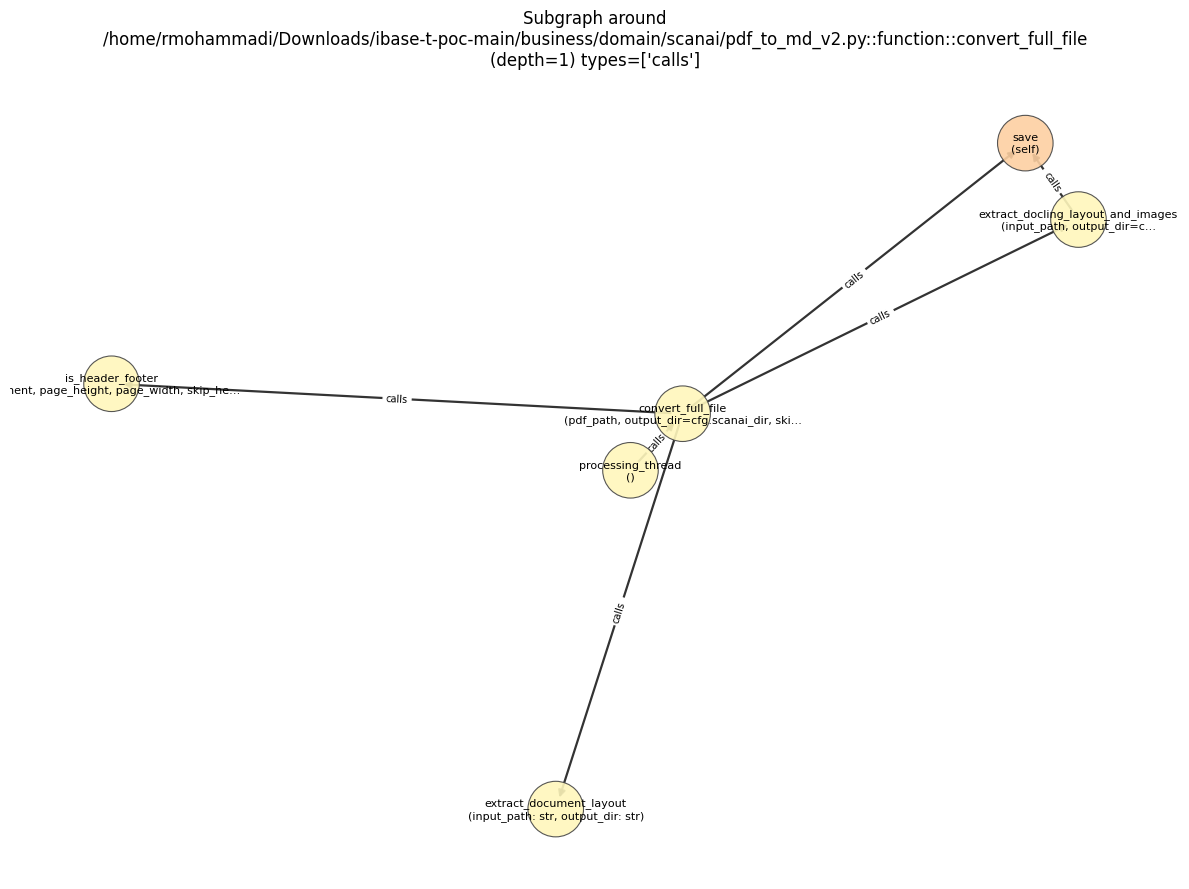

In [18]:
# Visualize only internal calls
visualize_internal_calls(G, center_node=center, depth=1)

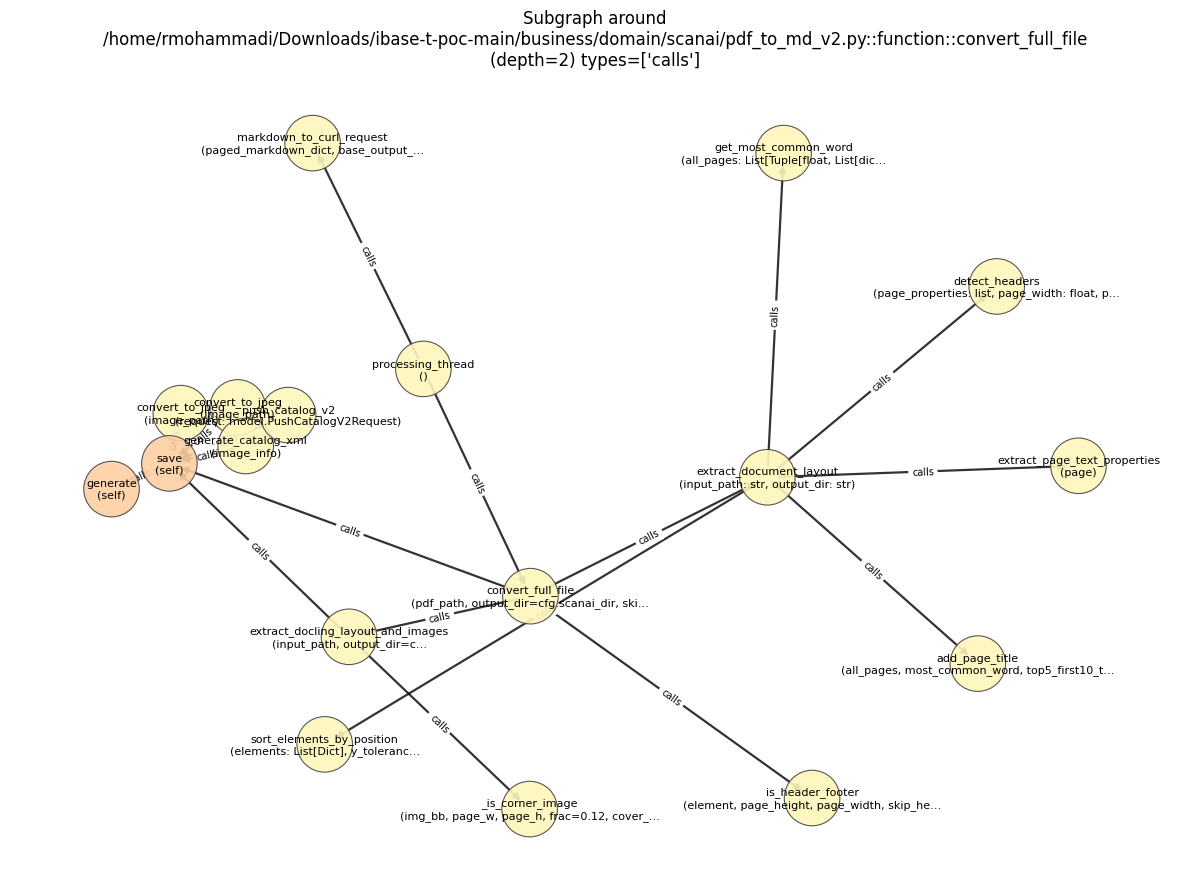

In [19]:
# Visualize only internal calls
visualize_internal_calls(G, center_node=center, depth=2)

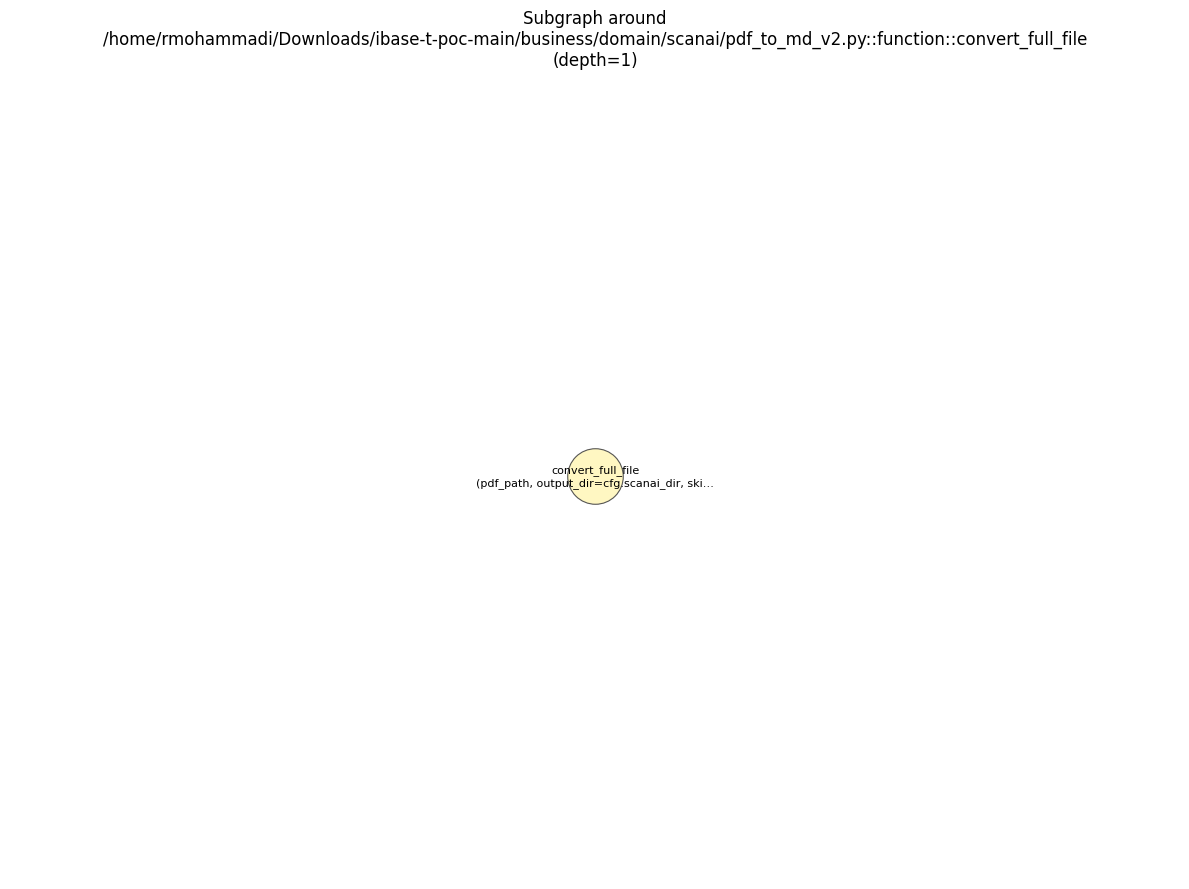

In [20]:

# (Or directly with visualize_subgraph)
visualize_subgraph(
    project_graph_for_visualization(G),
    center_node=center,
    depth=1,
    relation_types="calls",
    edge_where=[("internal","==",False)],
    node_where=[("type","in",{"function","method","lambda"})]
)

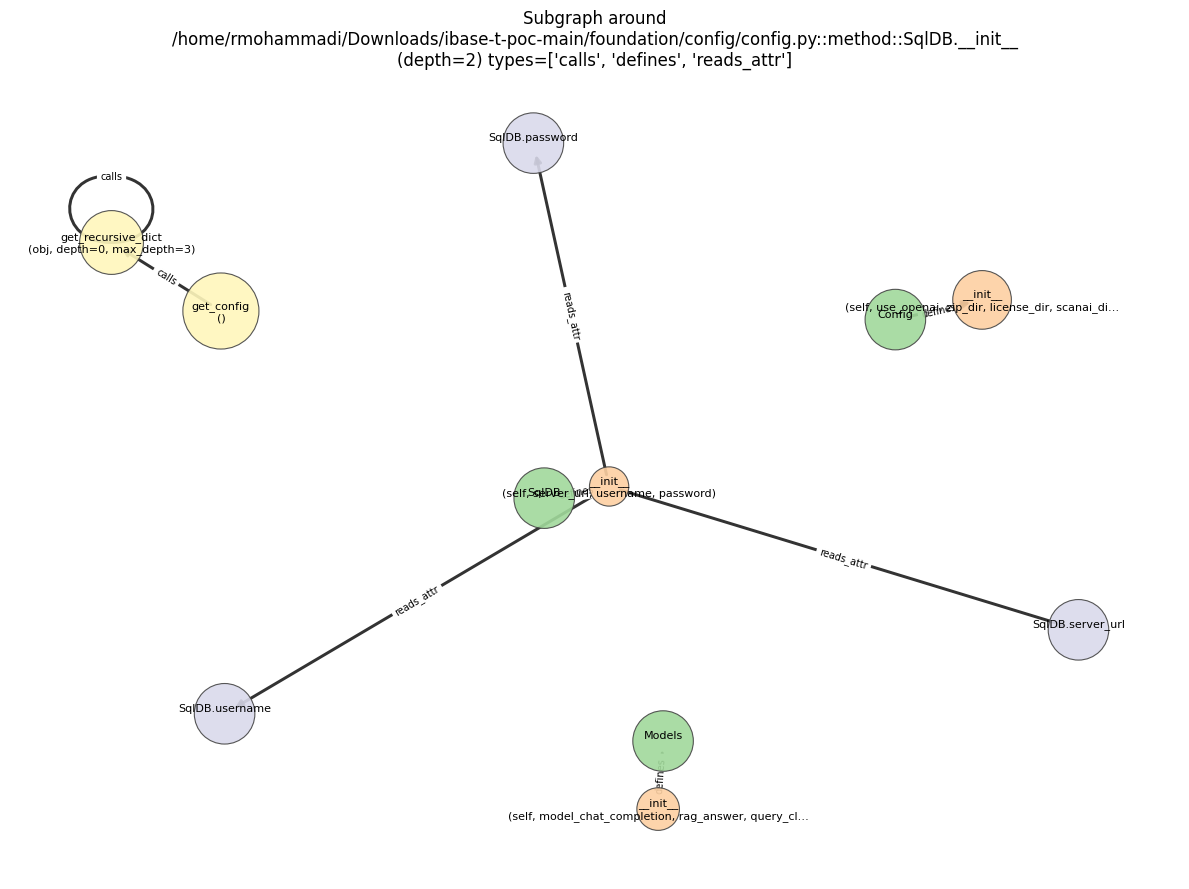

In [21]:
visualize_subgraph(
    project_graph_for_visualization(G),
    center_node="/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py::method::SqlDB.__init__",
    depth=2,
    relation_types=["defines","calls","reads_attr","writes_attr"],
    node_where=[("type","in",{"function","method","class","attribute"})],
    edge_where=None,
    size_by="metrics.n_loc",
    width_by="lineno",
    label_template="{name}\n{signature}"
)

Only functions/methods with at least 1 call, hide uses_module edges, and mark ambiguous call resolution:

Find a top-level function

['/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::function::convert_full_file']


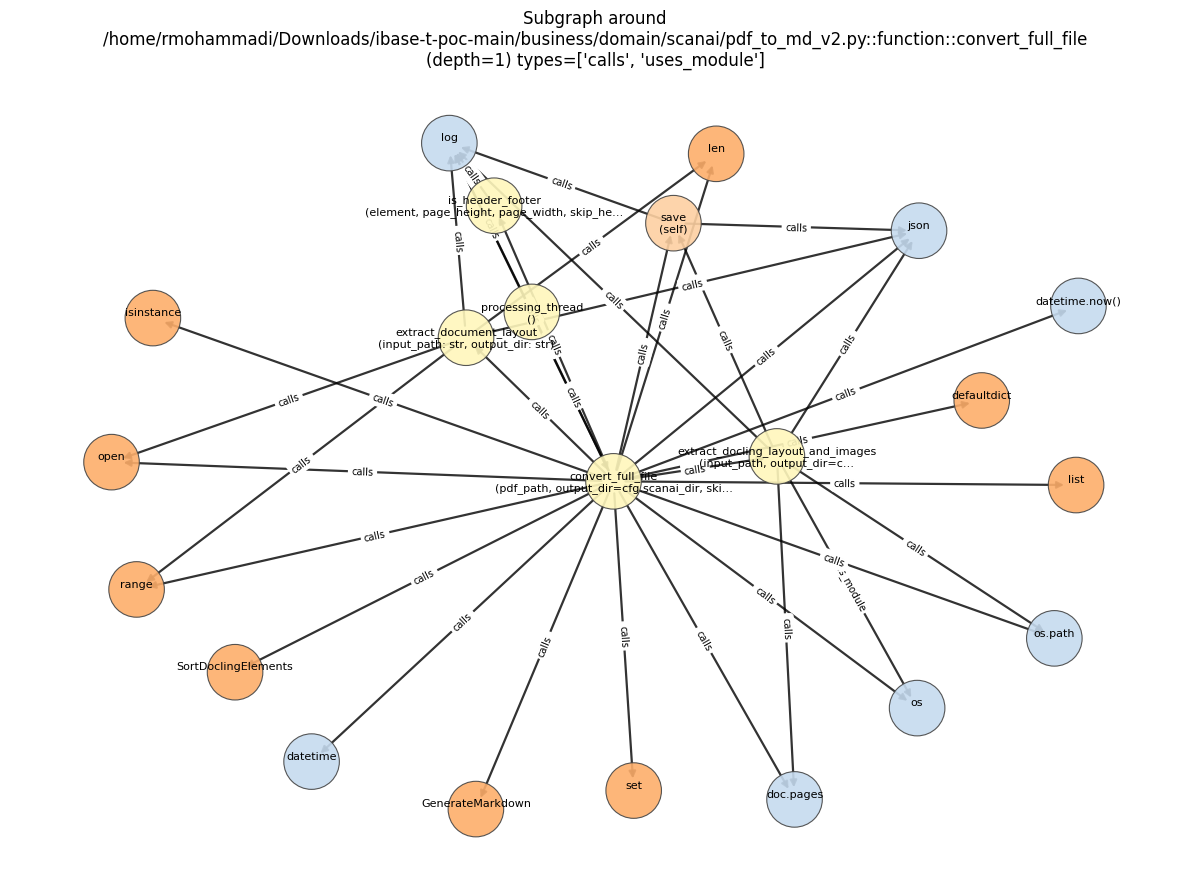

In [22]:
func_nodes = find_nodes_by_name(G, "convert_full_file", type_in={"function"})
print(func_nodes)

visualize_subgraph(project_graph_for_visualization(G), center_node=func_nodes[0], depth=1, relation_types="calls")


Find a class

['/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py::class::SqlDB']


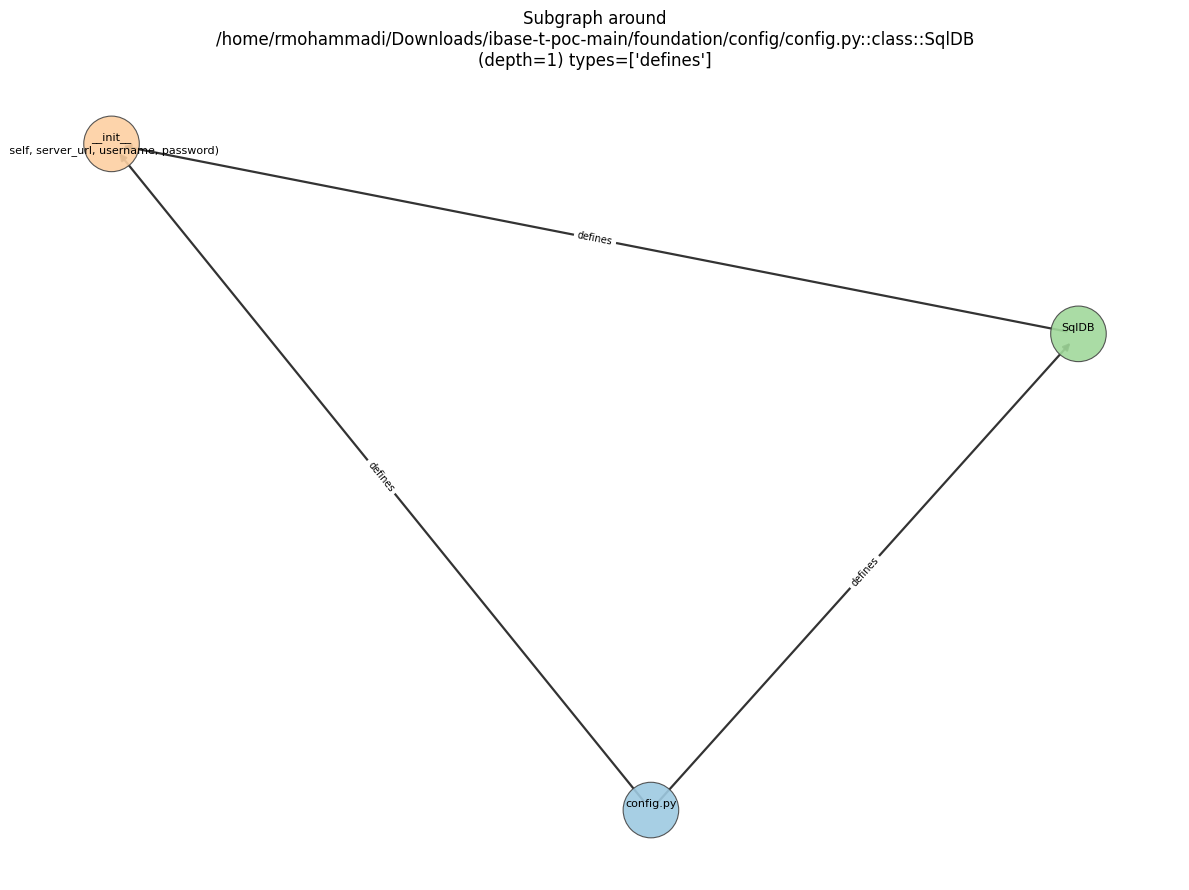

In [23]:
cls_nodes = find_nodes_by_name(G, "SqlDB", type_in={"class"})
print(cls_nodes)
# ['/abs/path/config.py::class::SqlDB']

visualize_subgraph(project_graph_for_visualization(G), center_node=cls_nodes[0], depth=1)

Find a method inside a class

['/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py::method::SqlDB.__init__']


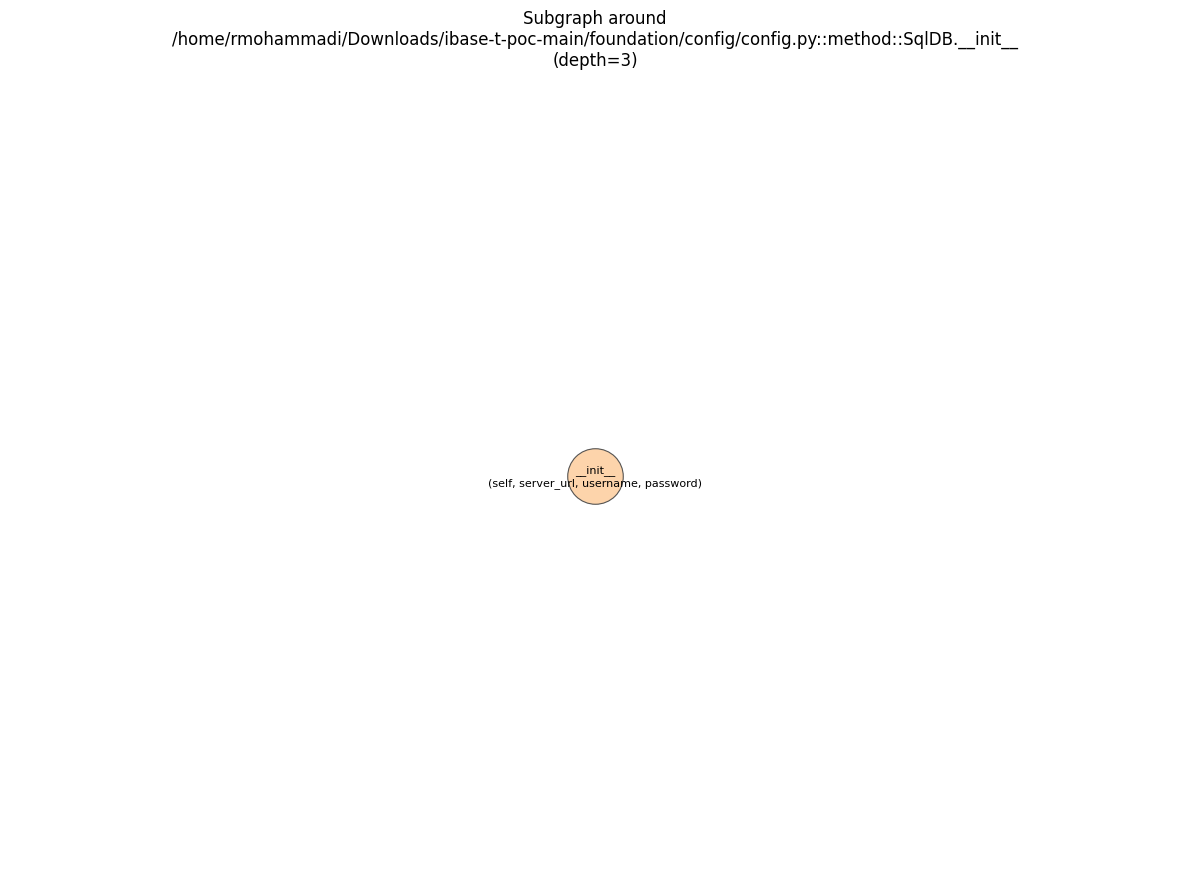

In [24]:
method_nodes = find_nodes_by_name(G, "__init__", type_in={"method"}, class_name="SqlDB")
print(method_nodes)

visualize_subgraph(project_graph_for_visualization(G), center_node=method_nodes[0], depth=3, relation_types="uses_module")

In [25]:
tests = find_nodes_by_name(G, r"^layout", type_in={"function"}, regex=True)
for t in tests:
    print("Test:", t)

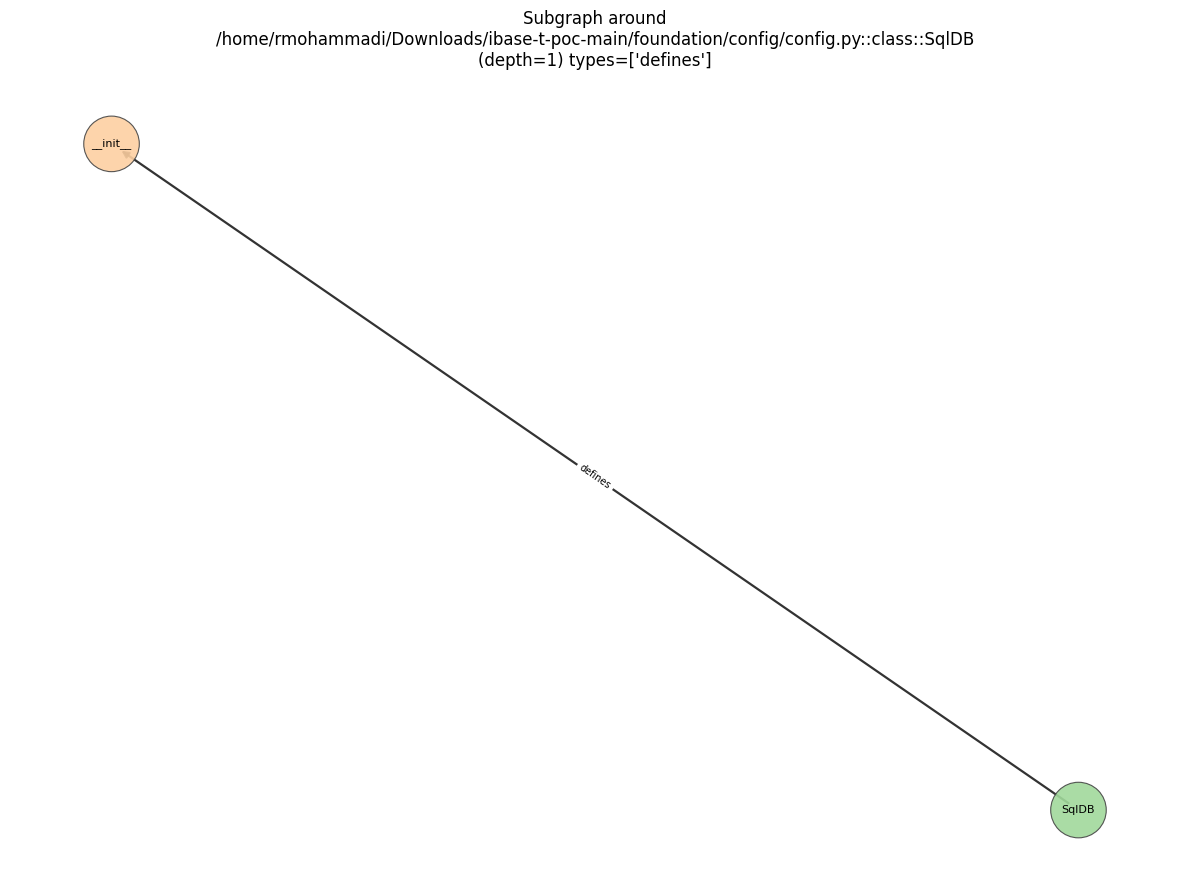

In [26]:
visualize_subgraph(
    G,
    center_node="/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py::class::SqlDB",
    depth=1,
    relation_types=["defines"],
    node_where=[("type","in",{"class","method"})],
    label_template="{name}"
)


In [33]:
def query_graph(G: nx.Graph, query: str) -> Optional[List[str]]:
    """
    Query and visualize a repository knowledge graph.

    This function interprets a small set of natural-language patterns and executes the
    corresponding NetworkX traversals and (optionally) a visualization via `visualize_subgraph`.
    It is SAFE to call with either a `nx.DiGraph` or a `nx.MultiDiGraph`. When given a
    MultiDiGraph, it attempts to aggregate parallel edges to a DiGraph using
    `project_graph_for_visualization`. If that helper is not available, a minimal
    internal fallback aggregation is used.

    Parameters
    ----------
    G : nx.Graph
        The repository knowledge graph. May be a DiGraph or MultiDiGraph produced by
        `build_knowledge_graph`.
    query : str
        Natural-language query. Case-insensitive. Supports optional flags.

    Supported Query Patterns
    ------------------------
    Calls / Callees:
      - "show all functions called by <FUNC>"
      - "show callees of <FUNC>"
      - "calls of <FUNC>"

    Callers:
      - "what calls <FUNC>"
      - "who calls <FUNC>"
      - "callers of <FUNC>"

    Class methods:
      - "visualize methods of <CLASS>"
      - "show methods of <CLASS>"

    Modules (imports):
      - "show modules used by <FUNC|CLASS>"
      - "modules of <FUNC>"
      - "imports of <FUNC>"

    Attributes:
      - "show attributes read by <FUNC|METHOD>"
      - "show attributes written by <FUNC|METHOD>"

    Exceptions:
      - "what does <FUNC> raise"
      - "raises of <FUNC>"

    Generic neighbors:
      - "neighbors of <NODE>"
      - "visualize neighbors of <NODE>"

    Optional Flags (can appear anywhere)
    ------------------------------------
      - depth <N>      or  depth=<N>        (default: 1)
      - internal       (keep edges with internal == True)
      - external       (keep edges with internal == False)

    Returns
    -------
    list[str] | None
        A list of matching neighbor node IDs for recognized queries. Returns None if
        the query cannot be resolved or an error occurs (errors are printed and suppressed).

    Error Handling
    --------------
    - Validates input types; prints an informative message and returns None on misuse.
    - If graph projection/aggregation fails, falls back to a minimal in-function aggregator.
    - Visualization errors are caught and reported without crashing the process.

    Examples
    --------
    >>> query_graph(G, "show modules used by parse convert_full_file")
    >>> query_graph(G, "what calls load_config depth 2")
    >>> query_graph(G, "visualize methods of MyClass")
    """
    import re

    # ---------- Basic validation ----------
    if not isinstance(query, str):
        print("query_graph: 'query' must be a string.")
        return None
    if not isinstance(G, (nx.DiGraph, nx.MultiDiGraph)):
        print("query_graph: 'G' must be a networkx DiGraph or MultiDiGraph.")
        return None

    # ---------- Normalize & extract flags ----------
    raw = query.strip()
    q = raw.lower()

    # depth flag
    depth = 1
    try:
        m_depth = re.search(r"\bdepth\s*=?\s*(\d+)\b", q)
        if m_depth:
            depth = int(m_depth.group(1))
            q = q[:m_depth.start()] + q[m_depth.end():]
    except Exception as e:
        print(f"query_graph: could not parse depth; defaulting to 1 ({e}).")
        depth = 1

    # internal/external flags (mutually exclusive; 'internal' wins if both present)
    internal_only = bool(re.search(r"\binternal(?:\s+only)?\b", q))
    external_only = (not internal_only) and bool(re.search(r"\bexternal(?:\s+only)?\b", q))
    q = re.sub(r"\b(internal(?:\s+only)?|external(?:\s+only)?)\b", "", q).strip()

    # ---------- Ensure DiGraph view for filtering/visuals ----------
    def _fallback_aggregate(M: nx.MultiDiGraph) -> nx.DiGraph:
        """Minimal in-place aggregator used only if projection helper is unavailable."""
        S = nx.DiGraph()
        S.add_nodes_from(M.nodes(data=True))
        for u, v in M.edges():
            edicts = list(M[u][v].values())
            # Compute minimal rollups we rely on in visuals/filters
            types = [ed.get("type") for ed in edicts]
            call_sites_count = sum(1 for t in types if t == "calls")
            ambiguous = any(ed.get("ambiguous") for ed in edicts)
            # Aggregate 'internal' by callee node type (project entity => internal True)
            callee_type = M.nodes[v].get("type")
            agg_internal = callee_type in {"function", "method", "lambda"}
            label_compact = f"calls ×{call_sites_count}" if call_sites_count else ",".join(sorted({t for t in types if t}))
            attrs = {
                "type": "calls" if "calls" in types else (sorted({t for t in types if t})[0] if any(types) else ""),
                "call_sites_count": call_sites_count,
                "ambiguous": ambiguous,
                "internal": agg_internal,
                "label_compact": label_compact,
            }
            if S.has_edge(u, v):
                # merge if needed
                prev = S[u][v]
                attrs["call_sites_count"] += prev.get("call_sites_count", 0)
                attrs["ambiguous"] = prev.get("ambiguous", False) or attrs["ambiguous"]
                attrs["internal"] = prev.get("internal", False) or attrs["internal"]
                if prev.get("type") == "calls":
                    attrs["type"] = "calls"
            S.add_edge(u, v, **attrs)
        return S

    Gq: nx.DiGraph
    try:
        if isinstance(G, nx.MultiDiGraph):
            # Prefer project_graph_for_visualization if present
            if "project_graph_for_visualization" in globals():
                Gq = project_graph_for_visualization(G)  # type: ignore[name-defined]
            else:
                print("query_graph: projection helper not found; using fallback aggregation.")
                Gq = _fallback_aggregate(G)
        else:
            Gq = G.copy()
    except Exception as e:
        print(f"query_graph: graph projection failed ({e}); using fallback aggregation.")
        try:
            Gq = _fallback_aggregate(G) if isinstance(G, nx.MultiDiGraph) else G.copy()
        except Exception as e2:
            print(f"query_graph: unable to create a queryable graph view ({e2}).")
            return None

    # ---------- Helpers ----------
    def _edge_pairs_out(u: str):
        try:
            for v in Gq.successors(u):
                yield v, Gq[u][v]
        except Exception:
            return

    def _edge_pairs_in(v: str):
        try:
            for u in Gq.predecessors(v):
                yield u, Gq[u][v]
        except Exception:
            return

    def _edge_passes(ed: Dict[str, Any], etype: Optional[str] = None) -> bool:
        try:
            if etype and ed.get("type") != etype:
                return False
            if internal_only and ed.get("internal") is not True:
                return False
            if external_only and ed.get("internal") is not False:
                return False
            return True
        except Exception:
            return False

    def _tokenize(name_str: str) -> List[str]:
        try:
            name_str = name_str.strip().strip('"\'')
            name_str = re.sub(r"\s+", " ", name_str)
            return [t for t in re.split(r"[ ,]+", name_str) if t]
        except Exception:
            return [name_str]

    def _resolve_node_smart(name_str: str, preferred_types: Optional[Iterable[str]] = None) -> Optional[str]:
        """
        Robust resolver for multi-token targets like "parse convert_full_file" or "MyClass.process".
        Prefers exact matches on the last token, then scores candidates by token coverage.
        Returns the best node id or None.
        """
        try:
            tokens = _tokenize(name_str)
            if not tokens:
                return None
            last = tokens[-1].lower()
            prefset = set(preferred_types) if preferred_types else None

            # exact name via helper
            if "find_nodes_by_name" in globals():
                try:
                    cands = find_nodes_by_name(Gq, last, type_in=prefset)  # type: ignore[name-defined]
                    if cands:
                        return cands[0]
                except Exception:
                    pass

            # exact on any token
            if "find_nodes_by_name" in globals():
                for tok in tokens:
                    try:
                        cands = find_nodes_by_name(Gq, tok.lower(), type_in=prefset)  # type: ignore[name-defined]
                        if cands:
                            return cands[0]
                    except Exception:
                        pass

            # dotted hint like Class.method or file.py
            dotted = next((tok for tok in tokens if "." in tok), None)
            if dotted:
                dotl = dotted.lower()
                for nid, data in Gq.nodes(data=True):
                    t = data.get("type")
                    if prefset and t not in prefset:
                        continue
                    name = str(data.get("name", "")).lower()
                    if name == dotl or dotl in name or dotl in nid.lower():
                        return nid

            # score-based ranking over all nodes
            def score_node(nid: str, data: Dict[str, Any]) -> float:
                scr = 0.0
                name = str(data.get("name", "")).lower()
                idl = nid.lower()
                t = data.get("type")
                if name == last:
                    scr += 2.0
                for tok in tokens:
                    tl = tok.lower()
                    if tl in name:
                        scr += 1.0
                    if tl in idl:
                        scr += 0.5
                if prefset and t in prefset:
                    scr += 0.5
                return scr

            pool: List[Tuple[float, str]] = []
            for nid, data in Gq.nodes(data=True):
                t = data.get("type")
                if preferred_types and t not in (prefset or set()):
                    # allow strong id match to survive filtering
                    if last in str(nid).lower():
                        pool.append((score_node(nid, data), nid))
                else:
                    pool.append((score_node(nid, data), nid))

            pool = [(s, n) for s, n in pool if s > 0]
            if not pool:
                return None

            def tie_rank(nid: str) -> Tuple[int, int]:
                t = Gq.nodes[nid].get("type")
                pri = {"function": 0, "method": 0, "lambda": 0, "class": 1, "file": 2,
                       "module": 3, "attribute": 4, "exception": 5}.get(t, 10)
                return (pri, len(str(Gq.nodes[nid].get("name", ""))))
            pool.sort(key=lambda sn: (-sn[0], *tie_rank(sn[1])))
            return pool[0][1]
        except Exception as e:
            print(f"query_graph: name resolution failed for '{name_str}' ({e}).")
            return None

    def _visualize(node: str, rel_types: Optional[Iterable[str]], node_filter: Optional[Sequence[Tuple[str, str, Any]]] = None) -> None:
        try:
            edge_where = []
            if internal_only: edge_where.append(("internal", "==", True))
            if external_only: edge_where.append(("internal", "==", False))
            visualize_subgraph(
                Gq,
                center_node=node,
                depth=depth,
                relation_types=rel_types,
                node_where=node_filter,
                edge_where=edge_where if edge_where else None,
                edge_label_key="label_compact",
                width_by="call_sites_count",
            )
        except Exception as e:
            print(f"query_graph: visualization failed ({e}).")

    # ---------- Pattern routing ----------
    try:
        # CALLEES
        m = re.match(r"^(?:show|visualize)\s+(?:all\s+)?(?:functions?\s+)?(?:called\s+by|callees\s+of|calls\s+of)\s+(.+)$", q)
        if m:
            name = m.group(1).strip()
            node = _resolve_node_smart(name, preferred_types={"function", "method", "lambda"})
            if not node:
                print(f"No function/method found matching '{name}'")
                return None
            succs = [s for s, ed in _edge_pairs_out(node) if _edge_passes(ed, etype="calls")]
            print(f"Functions called by {node}: {succs}")
            _visualize(node, rel_types=["calls"], node_filter=[("type", "in", {"function", "method", "lambda"})])
            return succs

        # CALLERS
        m = re.match(r"^(?:what|who)\s+calls\s+(.+)$", q) or re.match(r"^callers\s+of\s+(.+)$", q)
        if m:
            name = m.group(1).strip()
            node = _resolve_node_smart(name, preferred_types={"function", "method", "lambda"})
            if not node:
                print(f"No function/method found matching '{name}'")
                return None
            preds = [p for p, ed in _edge_pairs_in(node) if _edge_passes(ed, etype="calls")]
            print(f"{node} is called by: {preds}")
            _visualize(node, rel_types=["calls"], node_filter=[("type", "in", {"function", "method", "lambda"})])
            return preds

        # CLASS METHODS
        m = re.match(r"^(?:visualize|show)\s+methods?\s+of\s+(.+)$", q)
        if m:
            classname = m.group(1).strip()
            node = _resolve_node_smart(classname, preferred_types={"class"})
            if not node:
                print(f"No class found matching '{classname}'")
                return None
            succs = [s for s, ed in _edge_pairs_out(node) if _edge_passes(ed, etype="defines") and Gq.nodes[s].get("type") == "method"]
            print(f"Methods of {classname}: {succs}")
            _visualize(node, rel_types=["defines"], node_filter=[("type", "in", {"class", "method"})])
            return succs

        # MODULES USED (imports)
        m = re.match(r"^(?:show|visualize)\s+(?:modules?|imports)\s+(?:used\s+by|of)\s+(.+)$", q)
        if m:
            name = m.group(1).strip()
            node = _resolve_node_smart(name, preferred_types={"function", "method", "class"})
            if not node:
                print(f"No node found matching '{name}'")
                return None
            succs = [s for s, ed in _edge_pairs_out(node) if _edge_passes(ed, etype="uses_module")]
            print(f"Modules used by {node}: {succs}")
            _visualize(node, rel_types=["uses_module"], node_filter=[("type", "in", {"function", "method", "class", "module"})])
            return succs

        # ATTRIBUTES READ
        m = re.match(r"^(?:show|visualize)\s+attributes?\s+read\s+by\s+(.+)$", q)
        if m:
            name = m.group(1).strip()
            node = _resolve_node_smart(name, preferred_types={"method", "function"})
            if not node:
                print(f"No function/method found matching '{name}'")
                return None
            succs = [s for s, ed in _edge_pairs_out(node) if _edge_passes(ed, etype="reads_attr")]
            print(f"Attributes read by {node}: {succs}")
            _visualize(node, rel_types=["reads_attr"], node_filter=[("type", "in", {"method", "function", "attribute"})])
            return succs

        # ATTRIBUTES WRITTEN
        m = re.match(r"^(?:show|visualize)\s+attributes?\s+written\s+by\s+(.+)$", q)
        if m:
            name = m.group(1).strip()
            node = _resolve_node_smart(name, preferred_types={"method", "function"})
            if not node:
                print(f"No function/method found matching '{name}'")
                return None
            succs = [s for s, ed in _edge_pairs_out(node) if _edge_passes(ed, etype="writes_attr")]
            print(f"Attributes written by {node}: {succs}")
            _visualize(node, rel_types=["writes_attr"], node_filter=[("type", "in", {"method", "function", "attribute"})])
            return succs

        # RAISES
        m = re.match(r"^(?:what\s+does\s+(.+)\s+raise|raises\s+of\s+(.+))$", q)
        if m:
            name = (m.group(1) or m.group(2)).strip()
            node = _resolve_node_smart(name, preferred_types={"function", "method"})
            if not node:
                print(f"No function/method found matching '{name}'")
                return None
            succs = [s for s, ed in _edge_pairs_out(node) if _edge_passes(ed, etype="raises")]
            print(f"Exceptions raised by {node}: {succs}")
            _visualize(node, rel_types=["raises"], node_filter=[("type", "in", {"function", "method", "exception"})])
            return succs

        # NEIGHBORS (generic)
        m = re.match(r"^(?:neighbors\s+of|visualize\s+neighbors\s+of)\s+(.+)$", q)
        if m:
            name = m.group(1).strip()
            node = _resolve_node_smart(name, preferred_types=None)
            if not node:
                print(f"No node found matching '{name}'")
                return None
            succs = [s for s, ed in _edge_pairs_out(node) if _edge_passes(ed, etype=None)]
            preds = [p for p, ed in _edge_pairs_in(node) if _edge_passes(ed, etype=None)]
            neigh = sorted(set(succs + preds))
            print(f"Neighbors of {node}: {neigh}")
            _visualize(node, rel_types=None)
            return neigh

    except Exception as e:
        print(f"query_graph: unexpected error while processing query '{raw}' ({e}).")
        return None

    # ---------- No match ----------
    print("⚠️ Query not recognized. Try:\n"
          "  'show modules used by parse convert_full_file'\n"
          "  'show callees of main depth 2 internal'\n"
          "  'what calls load_config depth=2'\n"
          "  'visualize methods of MyClass'\n"
          "  'neighbors of Database'")
    return None

Functions called by /home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::function::convert_full_file: ['/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_analysis.py::function::extract_document_layout', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::function::extract_docling_layout_and_images', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::function::is_header_footer', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::method::GenerateMarkdown.save']


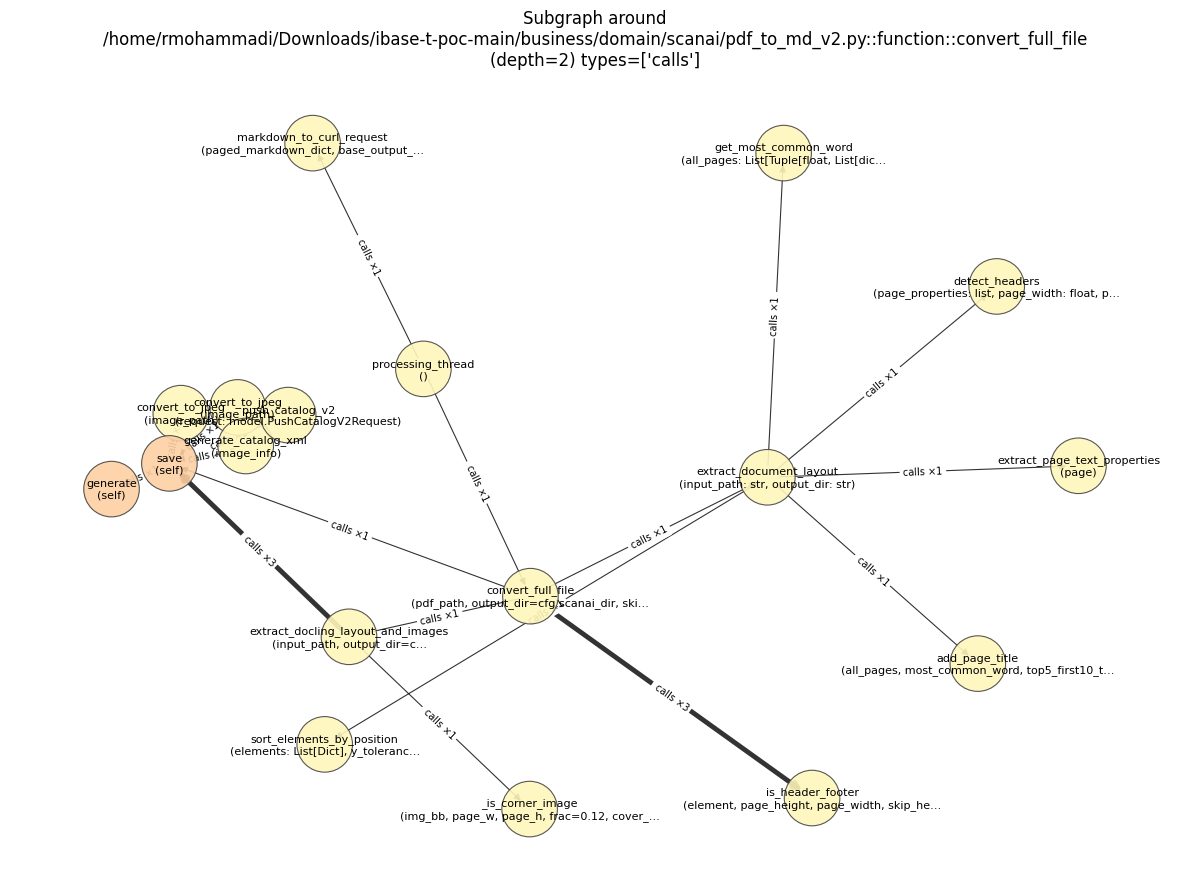

['/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_analysis.py::function::extract_document_layout',
 '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::function::extract_docling_layout_and_images',
 '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::function::is_header_footer',
 '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/pdf_to_md_v2.py::method::GenerateMarkdown.save']

In [36]:
query_graph(G, "show callees of main depth 2 internal by parse convert_full_file")


--- Example Queries ---
Functions called by /home/rmohammadi/Downloads/ibase-t-poc-main/api/tooling/data_intelligence/import_schemas/main.py: []


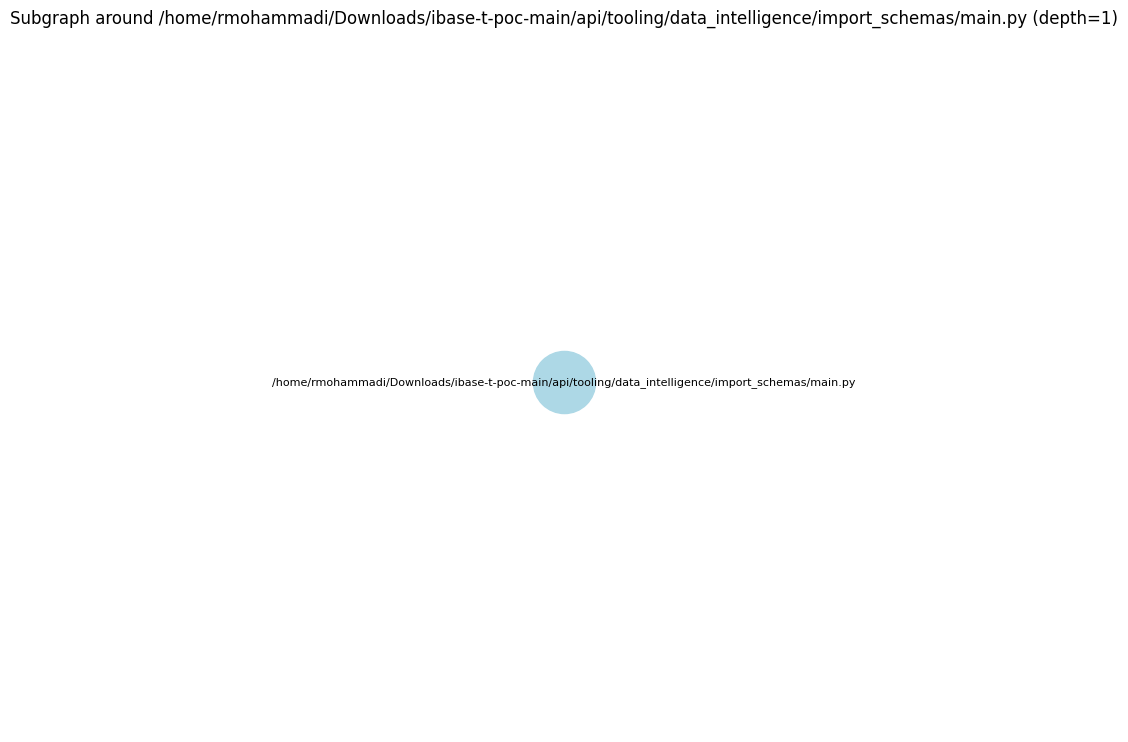

No class found matching stringprocessor
/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator_v2.py::function::clean_text is called by: ['/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator_v2.py::function::clean_part_name', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator.py::function::clean_part_name', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator.py::function::merge_chunks', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator.py::function::generate_xml', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/ata_xml_generator.py::function::extract_subtasks_from_markdown', '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/ata_xml_generator.py::function::generate_ata_xml']


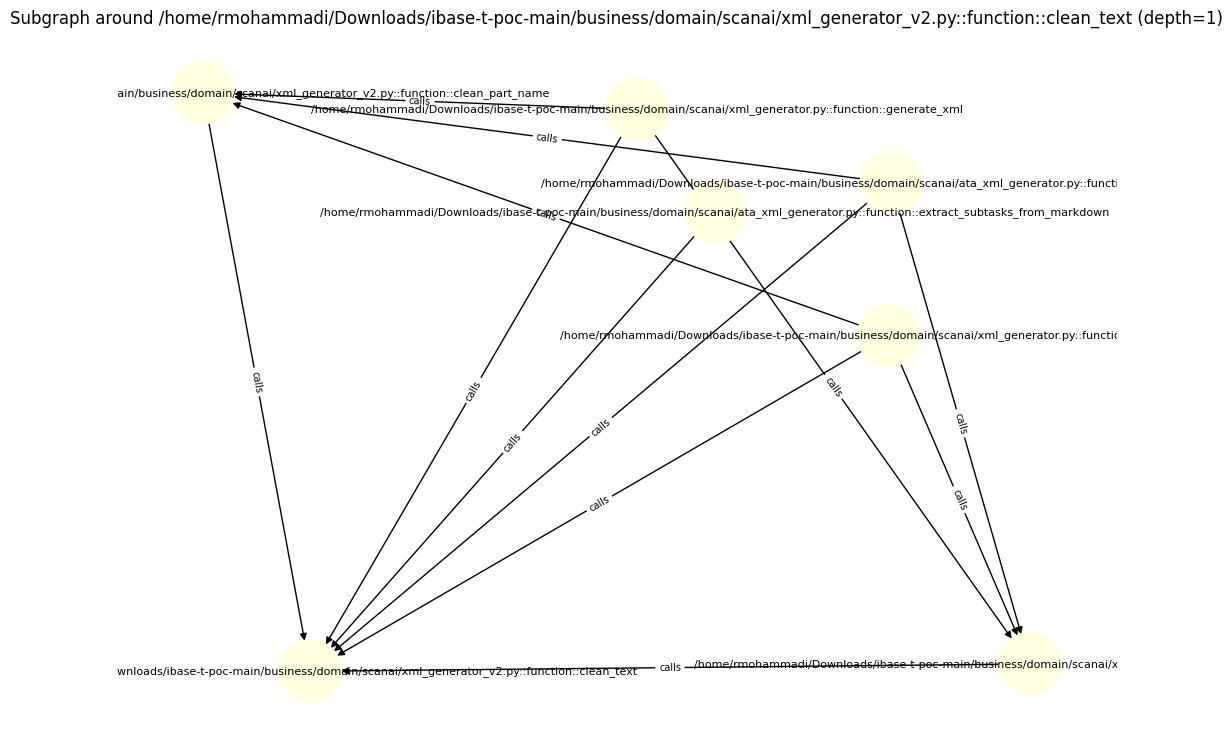

['/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator_v2.py::function::clean_part_name',
 '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator.py::function::clean_part_name',
 '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator.py::function::merge_chunks',
 '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/xml_generator.py::function::generate_xml',
 '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/ata_xml_generator.py::function::extract_subtasks_from_markdown',
 '/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/ata_xml_generator.py::function::generate_ata_xml']

In [63]:

# Example usage
print("\n--- Example Queries ---")
query_graph(G, "show all functions called by main")
query_graph(G, "visualize methods of StringProcessor")
query_graph(G, "what calls clean")


# ================================
# 4. Embeddings (local model)
# ================================

In [39]:
import math
from typing import List, Dict, Optional, Callable, Iterable
import numpy as np
import torch

def build_embeddings(
    chunks: List[Dict],
    model_name: str = "jinaai/jina-embeddings-v2-base-code",
    *,
    backend: str = "auto",                 # "auto" | "sentence-transformers" | "transformers"
    batch_size: int = 64,
    device: Optional[str] = None,          # None -> auto: cuda if available else cpu
    normalize: bool = True,                # L2 normalize output for cosine similarity
    max_length: Optional[int] = None,      # None -> sensible default per model family
    field_strategy: str = "code_only",     # "code_only" | "code_signature_doc" | "custom"
    text_builder: Optional[Callable[[Dict], str]] = None,  # used when field_strategy="custom"
) -> np.ndarray:
    """
    Build dense vector embeddings for code chunks using either a Sentence-Transformers
    model (preferred) or a plain HF Transformers model with robust pooling.

    Parameters
    ----------
    chunks : list of dict
        Each dict SHOULD include at least:
          - "code": str          (source of function/class/method)
        Optionally:
          - "name": str          (symbol name)
          - "signature": str     (function signature)
          - "docstring": str     (docstring)
          - "file": str          (path)
    model_name : str, default "jinaai/jina-embeddings-v2-base-code"
        HF Hub model id or local path.
        Good defaults for code listed below.
    backend : {"auto","sentence-transformers","transformers"}, default "auto"
        How to load/encode. "auto" tries Sentence-Transformers then falls back to Transformers.
    batch_size : int, default 64
        Encoding batch size.
    device : str or None, default None
        "cuda", "cpu" or "mps". None auto-selects "cuda" if available else "cpu".
    normalize : bool, default True
        L2-normalize embeddings row-wise (recommended for cosine similarity search).
    max_length : int or None
        Token length for truncation. If None, uses sensible defaults:
          - 8192 for Jina v2 code models
          - 512 for most others
    field_strategy : {"code_only","code_signature_doc","custom"}, default "code_only"
        How to compose the text that gets embedded:
          - "code_only": only the 'code' field
          - "code_signature_doc": signature + docstring + code (when present)
          - "custom": call `text_builder(chunk)` and embed that string
    text_builder : Callable or None
        Required when field_strategy="custom". Receives chunk dict, returns str.

    Returns
    -------
    np.ndarray
        Array of shape (N, D) float32, one embedding per chunk (in the same order).

    Raises
    ------
    ValueError
        - If `chunks` is empty or no chunk contains usable text.
        - If `field_strategy="custom"` but `text_builder` is None.

    Notes
    -----
    - Pooling strategy:
        * For BGE-* models: CLS pooling (per BAAI usage guide). :contentReference[oaicite:0]{index=0}
        * For GraphCodeBERT (base): mean pooling works; community ST variants also exist. :contentReference[oaicite:1]{index=1}
        * For Sentence-Transformers models: use `SentenceTransformer.encode`.
    - Long context:
        * Jina v2 base code supports ~8k tokens (we default to 8192 if not overridden). :contentReference[oaicite:2]{index=2}
    """
    if not isinstance(chunks, list) or len(chunks) == 0:
        raise ValueError("build_embeddings: 'chunks' must be a non-empty list.")
    if field_strategy == "custom" and not callable(text_builder):
        raise ValueError("build_embeddings: text_builder must be provided when field_strategy='custom'.")

    # ----------------------------
    # 1) Compose texts per chunk
    # ----------------------------
    def compose_text(ch: Dict) -> str:
        if field_strategy == "code_only":
            return str(ch.get("code", "") or "")
        elif field_strategy == "code_signature_doc":
            parts: List[str] = []
            if ch.get("name"):       parts.append(f"name: {ch['name']}")
            if ch.get("file"):       parts.append(f"file: {ch['file']}")
            if ch.get("signature"):  parts.append(f"signature: {ch['signature']}")
            if ch.get("docstring"):  parts.append(f"doc: {ch['docstring']}")
            code = ch.get("code", "") or ""
            parts.append("code:\n" + code)
            return "\n".join(parts)
        else:  # custom
            return str(text_builder(ch))

    texts: List[str] = [compose_text(ch) for ch in chunks]
    # Filter out completely empty texts but preserve alignment
    mask = [bool(t.strip()) for t in texts]
    if not any(mask):
        raise ValueError("build_embeddings: none of the chunks produced non-empty text to embed.")
    # Replace empty texts with a safe placeholder to keep indices aligned
    texts = [t if m else " " for t, m in zip(texts, mask)]

    # ----------------------------
    # 2) Device, max_length, helpers
    # ----------------------------
    if device is None:
        device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

    def _norm(x: np.ndarray) -> np.ndarray:
        if not normalize:
            return x.astype("float32", copy=False)
        denom = np.linalg.norm(x, axis=1, keepdims=True) + 1e-12
        return (x / denom).astype("float32", copy=False)

    # Heuristic default max_length
    name_lower = model_name.lower()
    if max_length is None:
        if "jina-embeddings-v2-base-code" in name_lower:
            max_length = 8192  # Jina v2 code supports 8k context. :contentReference[oaicite:3]{index=3}
        else:
            max_length = 512   # safe default for most HF encoder models

    # Detect families for pooling choice
    def _use_cls_pooling() -> bool:
        # BGE family recommends CLS pooling. :contentReference[oaicite:4]{index=4}
        return "baai/bge" in name_lower or "bge-" in name_lower

    # ----------------------------
    # 3) Try Sentence-Transformers
    # ----------------------------
    if backend in ("auto", "sentence-transformers"):
        try:
            from sentence_transformers import SentenceTransformer
            st_model = SentenceTransformer(model_name, device=device)
            try:
                # Respect model’s tokenizer max if smaller than requested
                st_model.max_seq_length = min(getattr(st_model, "max_seq_length", max_length), max_length)
            except Exception:
                pass

            embs = st_model.encode(
                texts,
                batch_size=batch_size,
                show_progress_bar=False,
                convert_to_numpy=True,
                normalize_embeddings=False,  # we normalize ourselves for consistency
            )
            return _norm(embs)
        except Exception as _st_err:
            if backend == "sentence-transformers":
                raise
            # else fall through to plain transformers backend

    # ----------------------------
    # 4) Plain Transformers fallback
    # ----------------------------
    from transformers import AutoTokenizer, AutoModel

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True, trust_remote_code=True)
    model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
    model.to(device)
    model.eval()

    def _mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        summed = (last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    pooled: List[np.ndarray] = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            toks = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            ).to(device)
            out = model(**toks)
            # Choose pooling
            if _use_cls_pooling():
                # Use first token (CLS) embedding
                vec = out.last_hidden_state[:, 0]
            else:
                # Default to mean pooling with attention mask
                vec = _mean_pool(out.last_hidden_state, toks["attention_mask"])
            pooled.append(vec.detach().cpu().numpy())

    embs = np.vstack(pooled)
    return _norm(embs)


In [38]:
# # 1) Code-specialized, long context (default in this function)
# emb = build_embeddings(chunks)  # uses jinaai/jina-embeddings-v2-base-code

# # 2) BGE-Code with CLS pooling (auto-detected)
# emb = build_embeddings(chunks, model_name="BAAI/bge-code-v1")

# # 3) GraphCodeBERT ST variant (pure Sentence-Transformers path)
# emb = build_embeddings(chunks, model_name="buelfhood/SOCO-C-GraphCodeBERT-ST")

# # 4) Compose richer text for retrieval: signature + docstring + code
# emb = build_embeddings(chunks, field_strategy="code_signature_doc")

# # 5) Custom text builder
# def my_builder(ch):
#     return f"{ch.get('file','')}\n{ch.get('name','')}\n{ch.get('signature','')}\n{ch.get('docstring','')}\n{ch.get('code','')}"
# emb = build_embeddings(chunks, field_strategy="custom", text_builder=my_builder)

# # 6) Tune batch, device, truncation
# emb = build_embeddings(
#     chunks,
#     model_name="BAAI/bge-code-v1",
#     batch_size=32,
#     device="cuda",
#     max_length=512
# )


# ================================
# 5. Build FAISS index
# ================================

In [41]:
relations[1]

{'caller_id': '/home/rmohammadi/Downloads/ibase-t-poc-main/foundation/config/config.py::function::get_config',
 'callee_name': 'getenv',
 'callee_fullname': 'os.getenv',
 'lineno': 63}

In [42]:
import numpy as np

def build_faiss_index(
    embeddings: np.ndarray,
    *,
    metric: str = "cosine",          # "cosine" | "l2" | "ip" (inner product / dot)
    index: str = "flat",             # "flat" | "ivf" | "hnsw"
    ids: np.ndarray | None = None,   # optional int64 ids to attach; default: 0..N-1
    normalize: bool | None = None,   # None -> infer; True -> L2-normalize; False -> assume already normalized
    # IVF params
    nlist: int = 1024,
    nprobe: int = 16,
    # HNSW params
    M: int = 32,
    efConstruction: int = 200,
    efSearch: int = 64,
    # GPU
    use_gpu: bool = False,
    gpu_device: int = 0,
    # Return extra info
    return_meta: bool = False,
):
    """
    Build a FAISS index for fast nearest-neighbor search over embeddings.

    Parameters
    ----------
    embeddings : np.ndarray, shape (N, D), dtype float32/float64
        Dense vectors (e.g., from `build_embeddings`). If metric="cosine",
        vectors MUST be L2-normalized. If not, set normalize=True or leave
        normalize=None (auto-infer & fix).
    metric : {"cosine","l2","ip"}, default "cosine"
        - "cosine" -> uses FAISS inner product on L2-normalized vectors
        - "l2"     -> Euclidean distance
        - "ip"     -> raw inner product (no normalization)
    index : {"flat","ivf","hnsw"}, default "flat"
        - "flat": exact search (IndexFlat*)
        - "ivf" : inverted lists (IndexIVFFlat) — must be trained
        - "hnsw": graph-based (IndexHNSWFlat)
    ids : np.ndarray[int64] | None
        Custom IDs to attach (length N). If None, uses [0..N-1].
    normalize : bool | None
        For metric="cosine":
          - True  -> L2-normalize a copy of embeddings before indexing
          - False -> assume embeddings already normalized (warn if not)
          - None  -> infer by checking norms; normalize if needed
        Ignored for "l2" and "ip".
    nlist, nprobe : IVF params
    M, efConstruction, efSearch : HNSW params
    use_gpu : bool
        Try to move index to GPU (falls back to CPU if unavailable).
    return_meta : bool
        If True, return (index, meta_dict).

    Returns
    -------
    faiss.Index or (faiss.Index, dict)
        Ready for `.search(Q, k)`. If return_meta=True, also returns:
        {
          "dim", "metric", "faiss_metric", "index_type",
          "nlist","nprobe","M","efConstruction","efSearch",
          "used_gpu","normalized_for_cosine","num_vectors"
        }

    Notes
    -----
    - For COSINE search, normalize query vectors the same way before searching:
        q = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-12)
    """
    try:
        import faiss
    except Exception as e:
        raise RuntimeError("FAISS is not installed. Install `faiss-cpu` or `faiss-gpu`.") from e

    # ------------------------- validation -------------------------
    if not isinstance(embeddings, np.ndarray) or embeddings.ndim != 2:
        raise ValueError("embeddings must be a 2D numpy array of shape (N, D).")
    N, D = embeddings.shape
    if N == 0 or D == 0:
        raise ValueError(f"embeddings must have non-zero shape; got ({N}, {D}).")

    # ids
    if ids is None:
        ids = np.arange(N, dtype=np.int64)
    else:
        ids = np.asarray(ids)
        if ids.dtype != np.int64:
            ids = ids.astype(np.int64, copy=False)
        if ids.shape != (N,):
            raise ValueError(f"ids must have shape (N,), got {ids.shape} for N={N}.")
        if len(np.unique(ids)) != N:
            raise ValueError("ids must be unique.")

    # dtype & contiguity
    X = embeddings.astype(np.float32, copy=False)
    if not X.flags["C_CONTIGUOUS"]:
        X = np.ascontiguousarray(X, dtype=np.float32)

    # ------------------------- metric handling -------------------------
    metric_l = metric.lower()
    if metric_l not in {"cosine", "l2", "ip", "inner_product", "dot"}:
        raise ValueError(f"Unsupported metric '{metric}'. Use 'cosine', 'l2', or 'ip'.")
    if metric_l in {"inner_product", "dot"}:
        metric_l = "ip"

    use_ip = (metric_l in {"cosine", "ip"})
    faiss_metric = faiss.METRIC_INNER_PRODUCT if use_ip else faiss.METRIC_L2

    # For cosine: ensure L2 normalization (either provided or inferred)
    normalized_used = False
    if metric_l == "cosine":
        if normalize is None:
            norms = np.linalg.norm(X, axis=1)
            if not np.all(np.isfinite(norms)) or np.max(np.abs(norms - 1.0)) > 1e-3:
                X = X / (norms[:, None] + 1e-12)
                normalized_used = True
            else:
                normalized_used = True  # already normalized
        elif normalize:
            norms = np.linalg.norm(X, axis=1)
            X = X / (norms[:, None] + 1e-12)
            normalized_used = True
        else:
            norms = np.linalg.norm(X, axis=1)
            if np.max(np.abs(norms - 1.0)) > 5e-2:
                print("build_faiss_index: warning: metric='cosine' but vectors do not appear normalized.")
            normalized_used = False

    # ------------------------- index construction -------------------------
    def _make_flat():
        return faiss.IndexFlatIP(D) if use_ip else faiss.IndexFlatL2(D)

    def _make_ivf(nlist_val: int):
        quantizer = _make_flat()
        return faiss.IndexIVFFlat(quantizer, D, int(nlist_val), faiss_metric)

    def _make_hnsw():
        try:
            h = faiss.IndexHNSWFlat(D, int(M), faiss_metric)
        except TypeError:
            h = faiss.IndexHNSWFlat(D, int(M))
        h.hnsw.efConstruction = int(efConstruction)
        h.hnsw.efSearch = int(efSearch)
        return h

    idx_type = index.lower()
    if idx_type == "flat":
        base = _make_flat()
    elif idx_type == "ivf":
        # ensure nlist reasonable for the dataset size
        nlist_eff = int(nlist)
        if N < nlist_eff:
            nlist_eff = max(1, int(max(1, round(np.sqrt(N)))))
        base = _make_ivf(nlist_eff)
    elif idx_type == "hnsw":
        base = _make_hnsw()
    else:
        raise ValueError(f"Unsupported index '{index}'. Use 'flat', 'ivf', or 'hnsw'.")

    # Train IVF on CPU (simplest); set nprobe
    if hasattr(base, "is_trained") and not base.is_trained:
        base.train(X)
    if hasattr(base, "nprobe"):
        base.nprobe = int(nprobe)

    # ------------------------- optional GPU -------------------------
    used_gpu = False
    if use_gpu:
        try:
            res = faiss.StandardGpuResources()
            base = faiss.index_cpu_to_gpu(res, int(gpu_device), base)
            used_gpu = True
            # re-apply nprobe if IVF on GPU
            if hasattr(base, "nprobe"):
                base.nprobe = int(nprobe)
        except Exception as e:
            print(f"build_faiss_index: GPU requested but unavailable; using CPU. ({e})")
            used_gpu = False

    # Wrap with ID map (IndexIDMap2 preferred)
    try:
        idmap = faiss.IndexIDMap2(base)
    except Exception:
        idmap = faiss.IndexIDMap(base)

    # Add vectors
    idmap.add_with_ids(X, ids)

    if return_meta:
        meta = {
            "dim": D,
            "metric": metric_l,
            "faiss_metric": "IP" if use_ip else "L2",
            "index_type": idx_type,
            "nlist": int(nlist if idx_type == "ivf" else 0) or (base.nlist if hasattr(base, "nlist") else None),
            "nprobe": int(nprobe) if idx_type == "ivf" else None,
            "M": int(M) if idx_type == "hnsw" else None,
            "efConstruction": int(efConstruction) if idx_type == "hnsw" else None,
            "efSearch": int(efSearch) if idx_type == "hnsw" else None,
            "used_gpu": used_gpu,
            "normalized_for_cosine": normalized_used if metric_l == "cosine" else None,
            "num_vectors": int(N),
        }
        return idmap, meta

    return idmap


In [ ]:
import numpy as np
import re
from typing import Any, Callable, Dict, List, Optional, Sequence

def semantic_search(
    query: str,
    embed_model: Any,                 # SentenceTransformer OR callable(texts)->np.ndarray
    index,                            # faiss.Index(…)
    chunks: List[Dict],
    *,
    top_k: int = 5,
    metric: Optional[str] = None,     # "cosine" | "l2" | "ip" ; if None, try to infer/assume cosine
    normalize_query: Optional[bool] = None,  # for cosine; None=auto
    index_meta: Optional[Dict] = None # optional meta returned by build_faiss_index(return_meta=True)
) -> List[Dict]:
    """
    Perform semantic search over a codebase using embeddings + FAISS.

    Parameters
    ----------
    query : str
        Natural-language text or code snippet.
    embed_model : object or callable
        - SentenceTransformers model with `.encode([text])`, OR
        - Callable that takes List[str] and returns np.ndarray (Q, D).
    index : faiss.Index
        FAISS index built from code embeddings.
    chunks : list[dict]
        Parsed chunks; must align with the ids used when building the index
        (typically ids = 0..N-1 in same order as `chunks`).
    top_k : int
        Number of nearest neighbors to return.
    metric : str or None
        If provided, one of {"cosine","l2","ip"}. If None, inferred from index_meta
        or defaults to "cosine".
    normalize_query : bool or None
        For cosine/IP: whether to L2-normalize query vectors. If None, auto-infer.
    index_meta : dict or None
        Optional metadata returned by build_faiss_index(..., return_meta=True).
        Used to infer metric and normalization.

    Returns
    -------
    list[dict]
        List of {"chunk": <chunk dict>, "distance": float, "score": float} ordered
        by descending score (higher is better). Distance semantics depend on metric.
    """
    if not isinstance(query, str) or not query.strip():
        raise ValueError("semantic_search: 'query' must be a non-empty string.")
    if not isinstance(chunks, list) or len(chunks) == 0:
        raise ValueError("semantic_search: 'chunks' must be a non-empty list.")

    # ---- infer metric & normalization intent ----
    m = (metric or (index_meta or {}).get("metric") or "cosine").lower()
    if m not in {"cosine", "l2", "ip", "inner_product", "dot"}:
        raise ValueError(f"semantic_search: unsupported metric '{m}'.")
    if m == "inner_product" or m == "dot":
        m = "ip"

    # ---- encode query vector ----
    if hasattr(embed_model, "encode"):
        q_vec = embed_model.encode([query], show_progress_bar=False)  # ST path
    elif callable(embed_model):
        q_vec = embed_model([query])  # custom callable
    else:
        raise TypeError("semantic_search: 'embed_model' must provide .encode([texts]) or be a callable(texts)->ndarray.")
    q_vec = np.asarray(q_vec, dtype=np.float32)
    if q_vec.ndim != 2 or q_vec.shape[0] != 1:
        raise ValueError(f"semantic_search: encoder returned shape {q_vec.shape}, expected (1, D).")

    # ---- normalize for cosine/IP if requested/inferred ----
    if m == "cosine" or m == "ip":
        # auto if not specified
        if normalize_query is None:
            # If the index_meta says it normalized database vectors, normalize query too
            normalized_db = (index_meta or {}).get("normalized_for_cosine", None)
            normalize_query = True if (m == "cosine" and normalized_db is not False) else False
        if normalize_query:
            denom = np.linalg.norm(q_vec, axis=1, keepdims=True) + 1e-12
            q_vec = q_vec / denom

    # ---- run search ----
    D, I = index.search(q_vec, int(top_k))

    # ---- unify scoring: higher 'score' is better; keep raw 'distance' too ----
    out: List[Dict] = []
    distances = D[0]
    indices = I[0]
    for d, idx in zip(distances, indices):
        if idx == -1:
            continue
        # Scoring:
        # - cosine (IndexIP): FAISS returns IP where higher is better -> score=d; distance ~ 1 - d
        # - ip              : same as above
        # - l2              : FAISS returns L2 distance; convert to a score using -distance
        if m in {"cosine", "ip"}:
            score = float(d)
            distance = float(1.0 - d)  # optional intuitive view
        else:  # l2
            score = float(-d)
            distance = float(d)
        # Map back to chunk
        try:
            chunk = chunks[int(idx)]
        except Exception:
            # If you used custom IDs, pass index_meta and a mapping instead.
            raise RuntimeError("semantic_search: chunk lookup failed. Ensure FAISS ids align with `chunks` or provide a mapping.")
        out.append({"chunk": chunk, "distance": distance, "score": score})

    # sort by score desc (FAISS usually returns sorted, but enforce)
    out.sort(key=lambda r: r["score"], reverse=True)
    return out


# ================================
# 6. Lexical regex search
# ================================

In [ ]:
import re
from typing import Dict, List, Iterable, Tuple, Optional

def lexical_search(
    query_text: str,
    chunks: List[Dict],
    *,
    fields: Iterable[str] = ("code", "name", "id", "file", "meta.docstring"),
    regex: bool = True,
    case_sensitive: bool = False,
    whole_word: bool = False,
    max_matches_per_chunk: int = 5,
) -> List[Dict]:
    """
    Regex/literal search over selected chunk fields with match metadata.

    Parameters
    ----------
    query_text : str
        Raw string or regex. If regex=False, the query is escaped (literal).
    chunks : list[dict]
        Parsed chunks as produced by the AST pipeline.
    fields : iterable of str
        Which fields to search. Supports dot path "meta.docstring".
    regex : bool
        If False, treat query as literal (re.escape).
    case_sensitive : bool
        Toggle case sensitivity (default False).
    whole_word : bool
        If True, wrap the pattern with \\b...\\b for token-like matching.
    max_matches_per_chunk : int
        Cap recorded matches per field to avoid huge payloads.

    Returns
    -------
    list[dict]
        Each item:
          {
            "chunk": <chunk dict>,
            "matched_fields": {
                "<field>": {"count": int, "spans": [(start,end), ... up to max_matches_per_chunk]}
            },
            "total_matches": int
          }
    """
    if not isinstance(query_text, str) or not query_text:
        raise ValueError("lexical_search: 'query_text' must be a non-empty string.")
    if not isinstance(chunks, list) or not chunks:
        return []

    pat = query_text if regex else re.escape(query_text)
    if whole_word:
        pat = r"\b" + pat + r"\b"
    flags = 0 if case_sensitive else re.IGNORECASE
    try:
        rx = re.compile(pat, flags)
    except re.error as e:
        raise ValueError(f"lexical_search: invalid regex: {e}")

    def get_field(ch: Dict, path: str) -> str:
        cur = ch
        for part in path.split("."):
            cur = cur.get(part, "") if isinstance(cur, dict) else ""
        return str(cur or "")

    results: List[Dict] = []
    for ch in chunks:
        matched_fields: Dict[str, Dict] = {}
        total = 0
        for f in fields:
            text = get_field(ch, f)
            if not text:
                continue
            spans: List[Tuple[int,int]] = []
            for m in rx.finditer(text):
                spans.append((m.start(), m.end()))
                total += 1
                if len(spans) >= max_matches_per_chunk:
                    break
            if spans:
                matched_fields[f] = {"count": len(spans), "spans": spans}
        if matched_fields:
            results.append({"chunk": ch, "matched_fields": matched_fields, "total_matches": total})

    # sort by total matches desc, then by code length asc as a tie-breaker
    results.sort(key=lambda r: (-r["total_matches"], len(r["chunk"].get("code",""))))
    return results


# ================================
# 7. Hybrid retrieval
# ================================

In [ ]:
from collections import deque
from typing import Set, Union

def retrieve_candidates(
    query_text: str,
    embed_model: Any,
    index,
    chunks: List[Dict],
    G,
    *,
    top_k_semantic: int = 5,
    metric: Optional[str] = None,
    index_meta: Optional[Dict] = None,
    # Lexical controls
    lex_fields: Iterable[str] = ("code", "name", "id", "file", "meta.docstring"),
    lex_regex: bool = True,
    lex_case_sensitive: bool = False,
    lex_whole_word: bool = False,
    # Graph expansion
    neighbor_depth: int = 1,
    relation_types: Optional[Iterable[str]] = ("calls", "defines"),  # add "reads_attr","writes_attr","uses_module","raises" if desired
    internal_only: Optional[bool] = None,   # True -> only edges with internal==True (if available)
    # Fusion
    use_rrf: bool = True,
    rrf_k: float = 60.0,
) -> List[Dict]:
    """
    Hybrid retrieval: semantic + lexical + graph expansion (MultiDiGraph-safe).

    Steps:
      1) Semantic (FAISS): top_k_semantic hits with metric-aware scoring.
      2) Lexical (regex/literal): matched chunks with counts/spans.
      3) Graph neighbors: BFS from current set, limited by depth and relation_types.

    Returns
    -------
    list[dict]
        Deduplicated candidate chunks ordered by a fused score if use_rrf=True,
        else by semantic score first then lexical counts, then graph proximity.
        Each item includes minimal provenance:
          {
            "chunk": <chunk dict>,
            "sources": {"semantic": score?, "lexical": count?, "graph_depth": d?},
            "score": <float>   # fused if enabled
          }
    """
    if not isinstance(chunks, list) or not chunks:
        return []

    # ---- fast id -> chunk map (no O(N) scans) ----
    id2chunk = {ch["id"]: ch for ch in chunks}

    # ---- 1) Semantic ----
    sem = semantic_search(
        query_text, embed_model, index, chunks,
        top_k=top_k_semantic, metric=metric, index_meta=index_meta
    )
    sem_ids = [r["chunk"]["id"] for r in sem]

    # ---- 2) Lexical ----
    lex = lexical_search(
        query_text, chunks,
        fields=lex_fields, regex=lex_regex,
        case_sensitive=lex_case_sensitive, whole_word=lex_whole_word
    )
    lex_ids = [r["chunk"]["id"] for r in lex]
    lex_counts = {r["chunk"]["id"]: r["total_matches"] for r in lex}

    # ---- Seed set ----
    seed_ids: List[str] = []
    seen: Set[str] = set()
    # keep semantic order then lexical
    for cid in sem_ids + lex_ids:
        if cid not in seen:
            seed_ids.append(cid); seen.add(cid)

    # ---- 3) Graph expansion (safe for DiGraph or MultiDiGraph) ----
    Gq = G
    try:
        import networkx as nx
        if isinstance(G, nx.MultiDiGraph) and "project_graph_for_visualization" in globals():
            Gq = project_graph_for_visualization(G)  # aggregate attributes (internal, type, label_compact…)
    except Exception:
        pass

    def _edge_ok(ed: Dict) -> bool:
        if relation_types:
            if ed.get("type") not in set(relation_types):
                return False
        if internal_only is True and ed.get("internal") is not True:
            return False
        if internal_only is False and ed.get("internal") is not False:
            return False
        return True

    graph_sources: Dict[str, int] = {}  # id -> minimal depth discovered
    for start in list(seed_ids):
        if start not in Gq:
            continue
        q = deque([(start, 0)])
        visited = {start}
        while q:
            nid, d = q.popleft()
            if d >= neighbor_depth:
                continue
            # successors + predecessors
            for nbr in list(Gq.successors(nid)) + list(Gq.predecessors(nid)):
                if nbr in visited:
                    continue
                ed = (Gq[nid][nbr] if Gq.has_edge(nid, nbr) else Gq[nbr][nid])  # works in DiGraph view
                if _edge_ok(ed):
                    visited.add(nbr)
                    q.append((nbr, d + 1))
                    # only add neighbors that are real chunks we know about
                    if nbr in id2chunk and nbr not in seen:
                        seen.add(nbr)
                        graph_sources[nbr] = d + 1

    # ---- merge all candidates & score (RRF fusion optional) ----
    # ranks: lower is better (1-based)
    sem_rank = {cid: i+1 for i, cid in enumerate(sem_ids)}
    lex_rank = {cid: i+1 for i, cid in enumerate(lex_ids)}
    # graph_rank is inverse of depth: closer neighbors get better (smaller) rank
    graph_rank = {cid: d for cid, d in graph_sources.items()}

    all_ids = list(dict.fromkeys(seed_ids + list(graph_sources.keys())))  # preserve order

    def rrf_score(cid: str) -> float:
        # Reciprocal Rank Fusion over available lists
        s = 0.0
        if cid in sem_rank: s += 1.0 / (rrf_k + sem_rank[cid])
        if cid in lex_rank: s += 1.0 / (rrf_k + lex_rank[cid])
        if cid in graph_rank and neighbor_depth > 0:
            # map depth 1..k onto pseudo-rank (depth 1 ~ rank 1.5)
            s += 1.0 / (rrf_k + (1.0 + graph_rank[cid]))
        return s

    results: List[Dict] = []
    for cid in all_ids:
        ch = id2chunk.get(cid)
        if not ch:
            continue
        src = {}
        if cid in sem_rank:
            # find semantic score for provenance
            srec = next((r for r in sem if r["chunk"]["id"] == cid), None)
            if srec is not None:
                src["semantic"] = float(srec["score"])
        if cid in lex_counts:
            src["lexical"] = int(lex_counts[cid])
        if cid in graph_sources:
            src["graph_depth"] = int(graph_sources[cid])
        results.append({
            "chunk": ch,
            "sources": src,
            "score": rrf_score(cid) if use_rrf else float(src.get("semantic", 0.0))
        })

    # Sort by fused score desc; stable by semantic then lexical if equal
    results.sort(key=lambda r: r["score"], reverse=True)
    return results


# ================================
# 8. Reranker (stubs)
# ================================

In [69]:
def simple_rerank(query: str, candidates: list[dict]):
    """
    Very simple re-ranking heuristic for candidate code chunks.

    This ranks candidate chunks based on whether the query text
    appears in their symbol `name`. Matches are ranked ahead of
    non-matches. This is a lightweight baseline reranker to order
    results after hybrid retrieval.

    Args:
        query (str):
            Natural language query or code symbol to prioritize.
            Example: "parse", "main", "ConfigLoader".

        candidates (list[dict]):
            Candidate chunks, as returned by `retrieve_candidates`.
            Each dict is expected to contain at least:
                - "id"   : unique identifier ("file::function::foo")
                - "name" : symbol name (function, class, or method)
                - "code" : code snippet (optional but useful)

    Returns:
        list[dict]:
            Ranked candidate chunks (same objects), sorted so that
            chunks whose `name` contains the query (case-insensitive)
            appear earlier.

    Notes:
        - This is a **heuristic-only** reranker.
        - It does not consider semantic embeddings or graph structure.
        - For production use, replace with LLM-based or embedding-based
          cross-encoder rerankers (e.g. HuggingFace `cross-encoder/ms-marco`).
        - Safe for quick testing because it has no external dependencies.

    Example:
        >>> cands = [
        ...     {"id": "file1::function::parse_xml", "name": "parse_xml", "code": "..."},
        ...     {"id": "file2::function::helper", "name": "helper", "code": "..."},
        ... ]
        >>> ranked = simple_rerank("parse", cands)
        >>> [c["id"] for c in ranked]
        ['file1::function::parse_xml', 'file2::function::helper']
    """
    q = query.lower()
    return sorted(
        candidates,
        key=lambda c: q in c.get("name", "").lower(),
        reverse=True
    )

# ================================
# 9. Final answer (stub)
# ================================

In [ ]:
from transformers import pipeline

# Load local LLM (can swap model for any HuggingFace checkpoint)
# For CPU testing, add: device_map="auto", torch_dtype="auto"
qa_pipeline = pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.2",  # or "tiiuae/falcon-7b-instruct"
    max_new_tokens=300,
    do_sample=True,
    temperature=0.3,
    top_p=0.9
)

def generate_answer_local(query: str, top_chunks: list[dict]) -> str:
    """
    Use a local Hugging Face LLM to generate an answer based on retrieved code.

    Args:
        query (str): User's natural language question.
        top_chunks (list[dict]): Top-ranked code chunks (with 'id' and 'code').

    Returns:
        str: LLM-generated answer conditioned on query and context.
    """
    # Prepare context
    context = "\n\n".join([f"{ch['id']}:\n{ch['code']}" for ch in top_chunks])

    # Build prompt
    prompt = (
        f"You are an expert Python code assistant. "
        f"Answer the following question based on the given context.\n\n"
        f"Question: {query}\n\n"
        f"Context:\n{context}\n\n"
        f"Answer:"
    )

    # Call the local HuggingFace model
    response = qa_pipeline(prompt)[0]["generated_text"]

    return response


# ================================
# 10. Example end-to-end run
# ================================

In [71]:
project_path = "/home/rmohammadi/Downloads/ibase-t-poc-main"

chunks, relations = parse_codebase(project_path)
print("Parsed chunks:", len(chunks))
print("Call relations:", len(relations))

Parsed chunks: 290
Call relations: 2225


In [72]:
G = build_knowledge_graph(chunks, relations)
print("Graph nodes:", len(G.nodes), "edges:", len(G.edges))

Graph nodes: 326 edges: 646


Functions called by /home/rmohammadi/Downloads/ibase-t-poc-main/api/tooling/data_intelligence/import_schemas/main.py: []


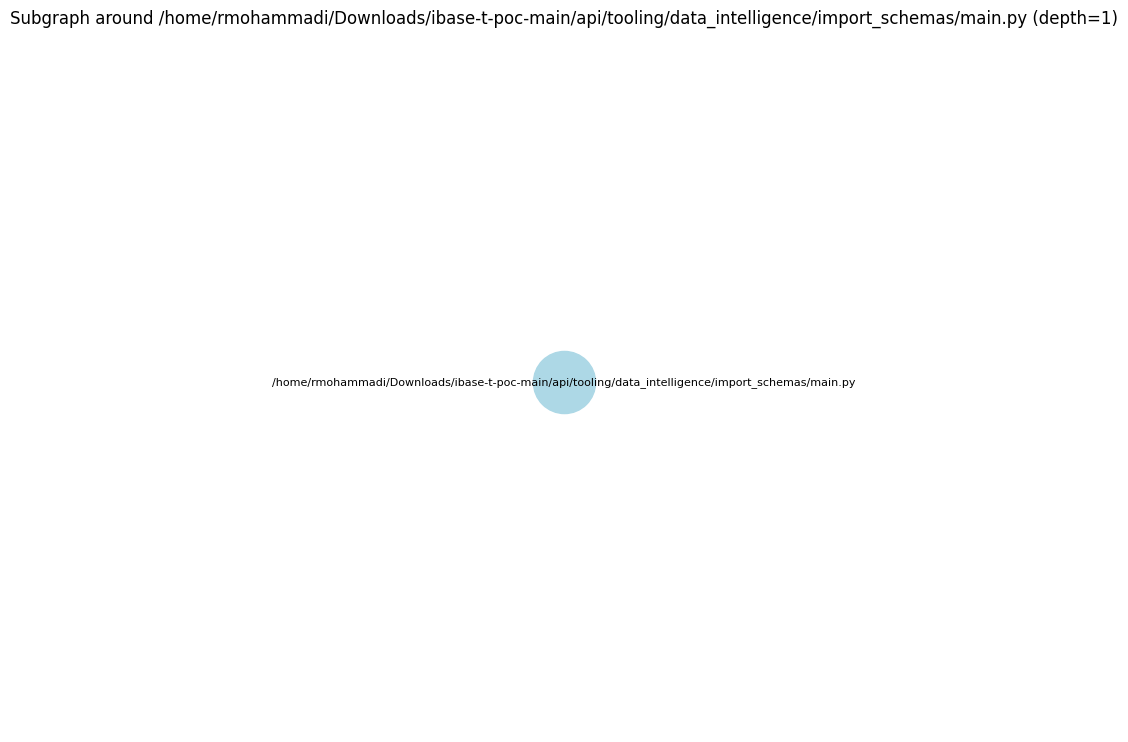

[]

In [43]:
# Example 1: Show all functions called by `main`
query_graph(G, "show all functions called by main")

In [73]:

# Example 2: Visualize methods of a class (replace with real class in your repo)
query_graph(G, "visualize methods of SomeClass")

No class found matching someclass


In [74]:
# Example 3: Find what calls a function
query_graph(G, "what calls run")

No function found matching run


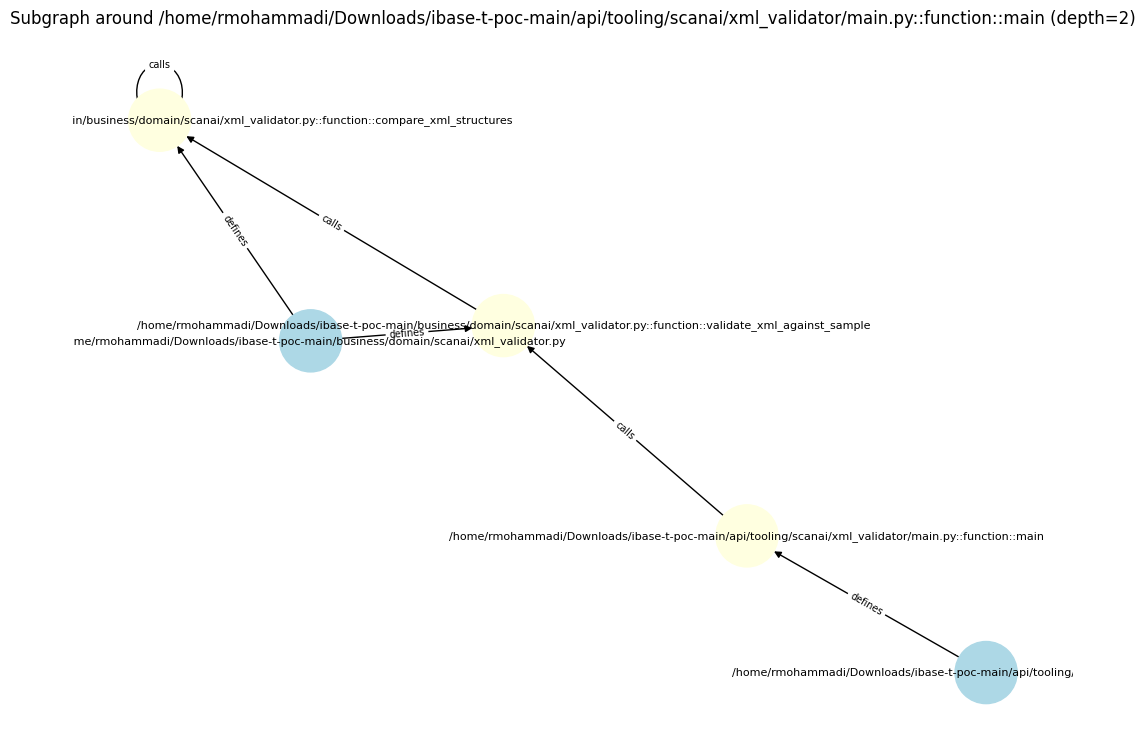

In [75]:

# Pick a function node (e.g., "main")
main_node = next((n for n in G.nodes if str(n).endswith("::function::main")), None)
if main_node:
    visualize_subgraph(G, center_node=main_node, depth=2)

## 5. Build embeddings + FAISS index

In [76]:
# Step 3: Embeddings + FAISS
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = build_embeddings(chunks, "sentence-transformers/all-MiniLM-L6-v2")
index = build_faiss_index(embeddings)

/home/rmohammadi/Downloads/Code_Gen/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


## 6. Semantic search

In [87]:
results = semantic_search("ScanAI", embed_model, index, chunks, top_k=3)
for r in results:
    print(r["chunk"]["id"], "distance:", r["distance"])
    print(r["chunk"]["code"][:200], "\n---")

/home/rmohammadi/Downloads/ibase-t-poc-main/app/domain/scanai/scanai.py::function::process_markdown distance: 1.2061357498168945
def process_markdown():
                    try:
                        for item in scanai.markdown_to_curl_request(markdowns, abs_output_dir):
                            yield item
                 
---
/home/rmohammadi/Downloads/ibase-t-poc-main/app/domain/scanai/scanai.py::function::processing_thread distance: 1.2270522117614746
def processing_thread():
                    try:
                        for item in scanai.markdown_to_curl_request(markdowns, abs_output_dir):
                            processing_queue.put(("ite 
---
/home/rmohammadi/Downloads/ibase-t-poc-main/app/domain/scanai/scanai.py::function::processing_thread distance: 1.3158783912658691
def processing_thread():
                    try:
                        for item in scanai.convert_full_file(pdf_path, output_dir=cfg.scanai_dir, skip_headers_footers=False):
                      

## 7. Lexical search (grep-style)

In [80]:
matches = lexical_search("Database", chunks)
for m in matches[:3]:
    print(m["id"], "\n", m["code"][:200], "\n---")

/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/data_intelligence/import_schemas.py::function::fetch_all_tables 
 def fetch_all_tables(connection):
    """
    Fetch all table names from the database.
    """
    cursor = connection.cursor()
    query = "SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABL 
---
/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/data_intelligence/import_schemas.py::function::connect_to_sql_server 
 def connect_to_sql_server(jdbc_url, username, password):
    """
    Connects to SQL Server using pyodbc.
    """
    jdbc_url = jdbc_url.replace("jdbc:sqlserver://", "")
    params = jdbc_url.split(" 
---
/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/data_intelligence/import_schemas.py::function::fetch_table_description 
 def fetch_table_description(connection, table_name):
    """
    Fetch table description (comment) from the database, or use LLM to generate one.
    """

    cursor = connection.cursor()
    try:
 

## 8. Hybrid retrieval

In [82]:
candidates = retrieve_candidates("how is authentication handled?", embed_model, index, chunks, G)
for c in candidates[:3]:
    print(c["id"], "\n", c["code"][:200], "\n---")

/home/rmohammadi/Downloads/ibase-t-poc-main/app/domain/digital_sme/digital_sme.py::function::api_key_auth 
 def api_key_auth(api_key: str = Depends(api_key_header)):
    if api_key != os.environ.get("API_KEY"):
        raise HTTPException(
                status_code=status.HTTP_401_UNAUTHORIZED,
           
---
/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/token_manager.py::method::TokenManager.get_token 
 def get_token(self, auth_type="default") -> str:
        """Get a valid token, refreshing only if expired or about to expire"""
        if self.is_token_valid():
            self.log.info(f"using exis 
---
/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/token_manager.py::function::get_token 
 def get_token(self, auth_type="default") -> str:
        """Get a valid token, refreshing only if expired or about to expire"""
        if self.is_token_valid():
            self.log.info(f"using exis 
---


## 9. Stubbed LLM answer

In [83]:
ranked = simple_rerank("authentication", candidates)
answer = generate_answer_stub("How is authentication handled?", ranked[:3])
print(answer)

Q: How is authentication handled?
Based on context:
/home/rmohammadi/Downloads/ibase-t-poc-main/app/domain/digital_sme/digital_sme.py::function::api_key_auth:
def api_key_auth(api_key: str = Depends(api_key_header)):
    if api_key != os.environ.get("API_KEY"):
        raise HTTPException(
                status_code=status.HTTP_401_UNAUTHORIZED,
                detail="Forbidden"
        )
    return True

/home/rmohammadi/Downloads/ibase-t-poc-main/business/domain/scanai/token_manager.py::method::TokenManager.get_token:
def get_token(self, auth_type="default") -> str:
        """Get a valid token, refreshing only if expired or about to expire"""
        if self.is_token_valid():
            self.log.info(f"using existing valid token")
            if self.token is None:
                raise HTTPException(status_code=500, detail="Token is unexpectedly None")
            return self.token

        self.log.info(f"token expired or about to expire, refreshing for auth type: {auth_type}..